In [5]:
import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("ticks")

H5AD_PATH = "/mnt/172/wh/25-12/spatial/preprocessed/GSE274447_spatial_perturb_seq.h5ad"
OUT_DIR   = "/root/code/nicheformer/output/0525/visualize_slides"
os.makedirs(OUT_DIR, exist_ok=True)

print("Loading data ...")
adata = sc.read_h5ad(H5AD_PATH)
print(f"Shape: {adata.shape}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"var names (first 10): {list(adata.var_names[:10])}")

Loading data ...
Shape: (229775, 22332)
obs columns: ['sample', 'x', 'y', 'dnbCount', 'area', 'sample_batch', 'perturbation', 'sgRNA', 'sgRNA_count']
var names (first 10): ['Stxbp1', 'Sdhb', 'Asb16', 'Actr2', 'Zwilch', 'Naa60', 'Zfp263', 'Slc5a10', '4930455M05Rik', 'Gins2']


In [6]:
SAMPLES = ["C02943C3", "B03018A2", "A03599E2"]

PERT_COLORS = {
    "Neg":      "#D3D3D3",
    "Clu":      "#E41A1C", "Fasn":     "#377EB8", "Olig2":    "#4DAF4A",
    "Stk39":    "#984EA3", "Trem2":    "#FF7F00", "Gfap":     "#FFFF33",
    "Sh3gl2":   "#A65628", "Rraga":    "#F781BF", "Flcn":     "#66C2A5",
    "Cfap410":  "#FC8D62", "Rbfox3":   "#8DA0CB", "Ndufaf2":  "#E78AC3",
    "Tbk1":     "#A6D854", "Msafe":     "#FFD92F", "Dpp5":     "#E5C494",
    "Srf":      "#B3B3B3", "C9orf72":  "#1B9E77", "Lrrk2":    "#D95F02",
}

print("="*70)
print("Per-slide perturbation summary")
print("="*70)

for sample in SAMPLES:
    mask = adata.obs["sample"] == sample
    sub = adata[mask]
    n = sub.n_obs
    vc = sub.obs["perturbation"].value_counts()
    n_pert = vc[vc.index != "Neg"].sum()
    print(f"\n{sample}: {n} cells, {n_pert} perturbed ({100*n_pert/n:.2f}%)")
    for pert, count in vc.head(10).items():
        bar = "█" * int(30 * count / vc.max())
        print(f"  {pert:20s}: {count:>6d}  {bar}")


Per-slide perturbation summary

C02943C3: 39862 cells, 176 perturbed (0.44%)
  Neg                 :  39686  ██████████████████████████████
  Clu                 :     30  
  Fasn                :     26  
  Stk39               :     24  
  Olig2               :     22  
  Rraga               :     10  
  Gfap                :      9  
  Trem2               :      8  
  Cfap410             :      8  
  Msafe               :      8  

B03018A2: 123921 cells, 4257 perturbed (3.44%)
  Neg                 : 119664  ██████████████████████████████
  Clu                 :    598  
  Fasn                :    536  
  Olig2               :    477  
  Stk39               :    461  
  Trem2               :    294  
  Gfap                :    260  
  Sh3gl2              :    221  
  Rraga               :    219  
  Flcn                :    215  

A03599E2: 65992 cells, 322 perturbed (0.49%)
  Neg                 :  65670  ██████████████████████████████
  Clu                 :     66  
  Olig2      

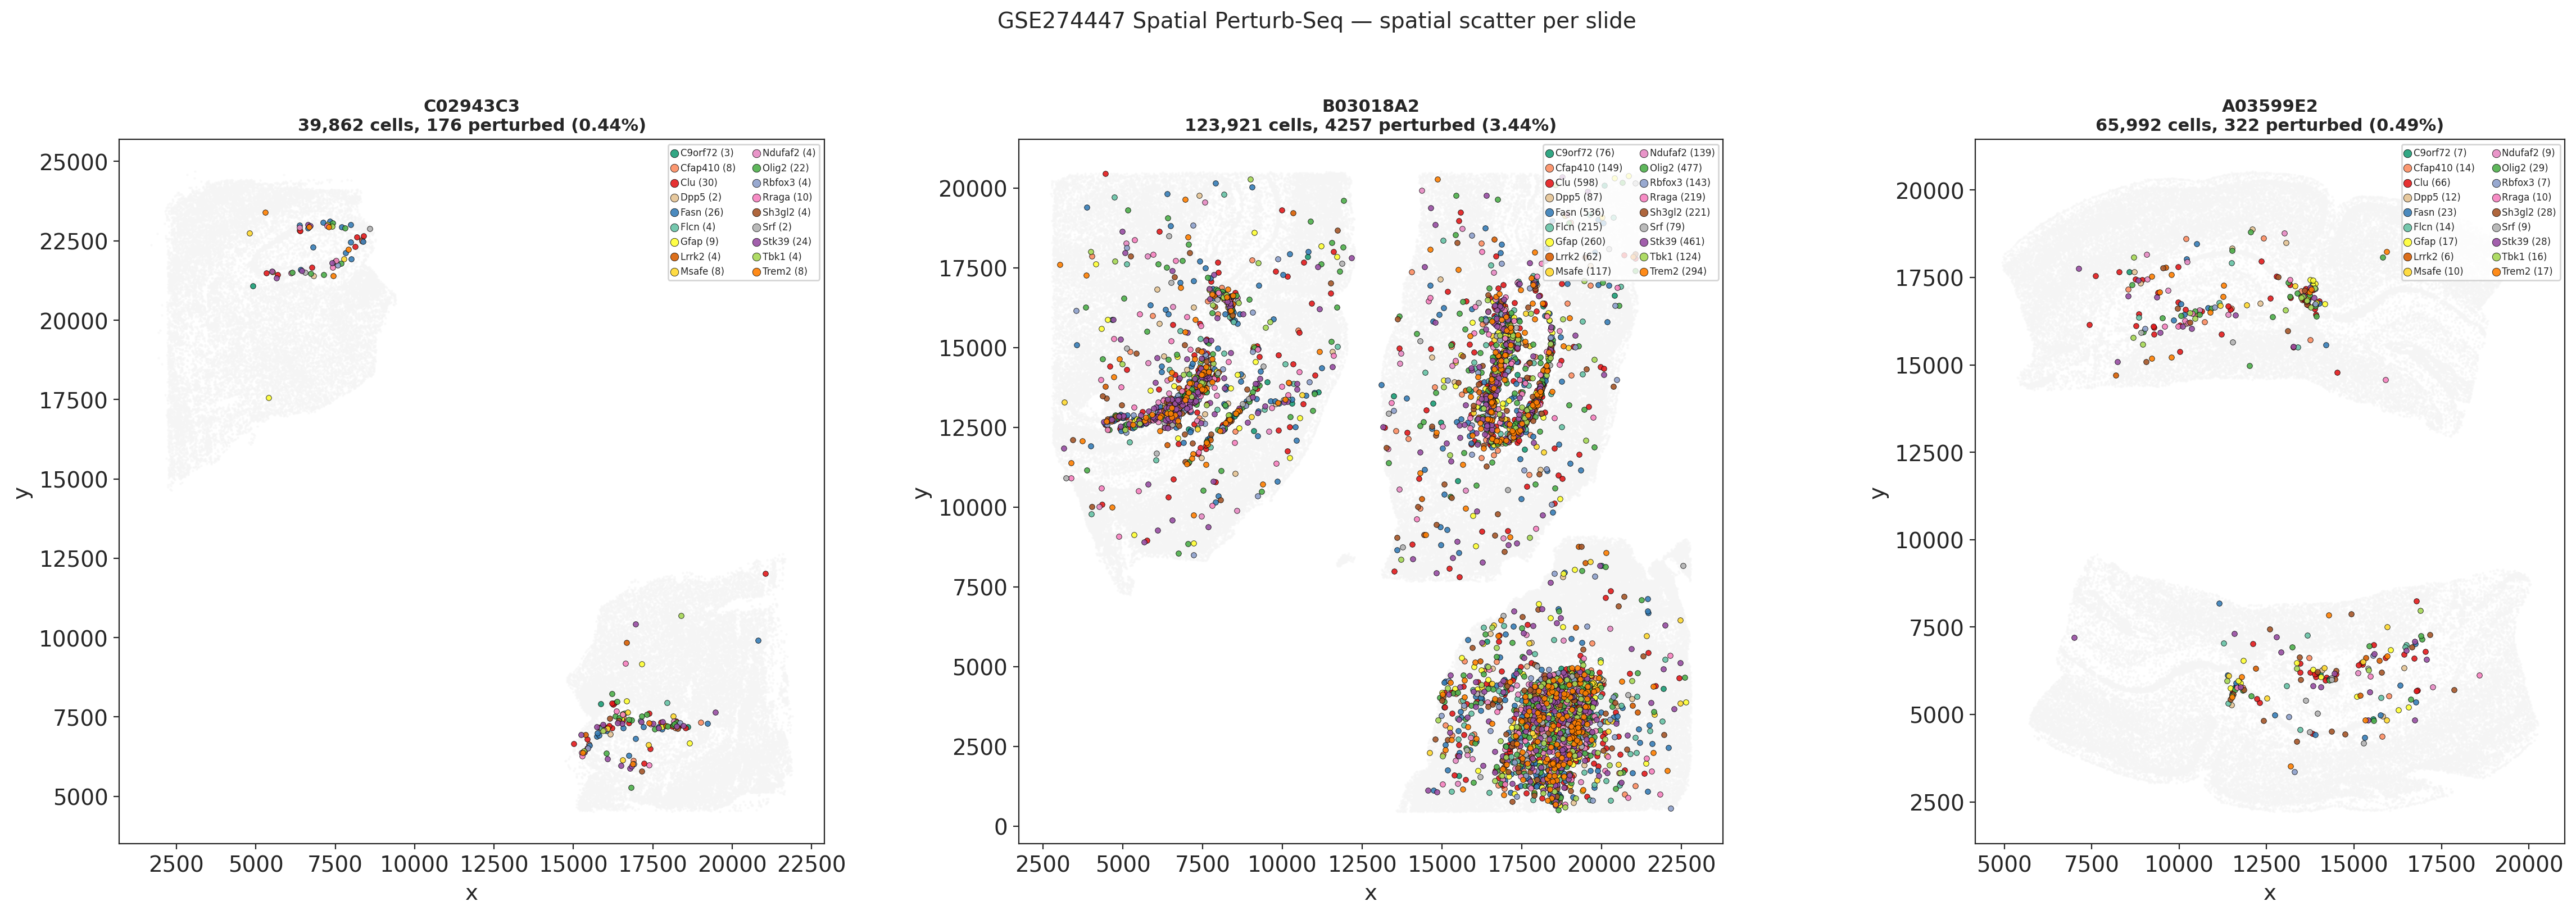

-> spatial_scatter_per_slide.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, sample in enumerate(SAMPLES):
    ax = axes[i]
    mask = adata.obs["sample"] == sample
    xy = adata.obsm["spatial"][mask]
    pert = adata.obs["perturbation"][mask].values

    # Background: all cells in light grey
    ax.scatter(xy[:, 0], xy[:, 1], c="#F5F5F5", s=0.3, alpha=0.6, rasterized=True)

    # Perturbed cells
    pert_mask = pert != "Neg"
    xy_p = xy[pert_mask]
    pert_p = pert[pert_mask]

    for p in sorted(set(pert_p)):
        p_mask = pert_p == p
        ax.scatter(xy_p[p_mask, 0], xy_p[p_mask, 1],
                   c=PERT_COLORS.get(p, "#000000"), s=12, alpha=0.9,
                   edgecolors="black", linewidth=0.3, rasterized=True,
                   label=f"{p} ({p_mask.sum()})")

    n_total = len(pert)
    n_pert = pert_mask.sum()
    ax.set_title(f"{sample}\n{n_total:,} cells, {n_pert} perturbed ({100*n_pert/n_total:.2f}%)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.legend(fontsize=6, markerscale=1.5, loc="upper right", frameon=True, ncol=2)

fig.suptitle("GSE274447 Spatial Perturb-Seq — spatial scatter per slide", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spatial_scatter_per_slide.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spatial_scatter_per_slide.png")


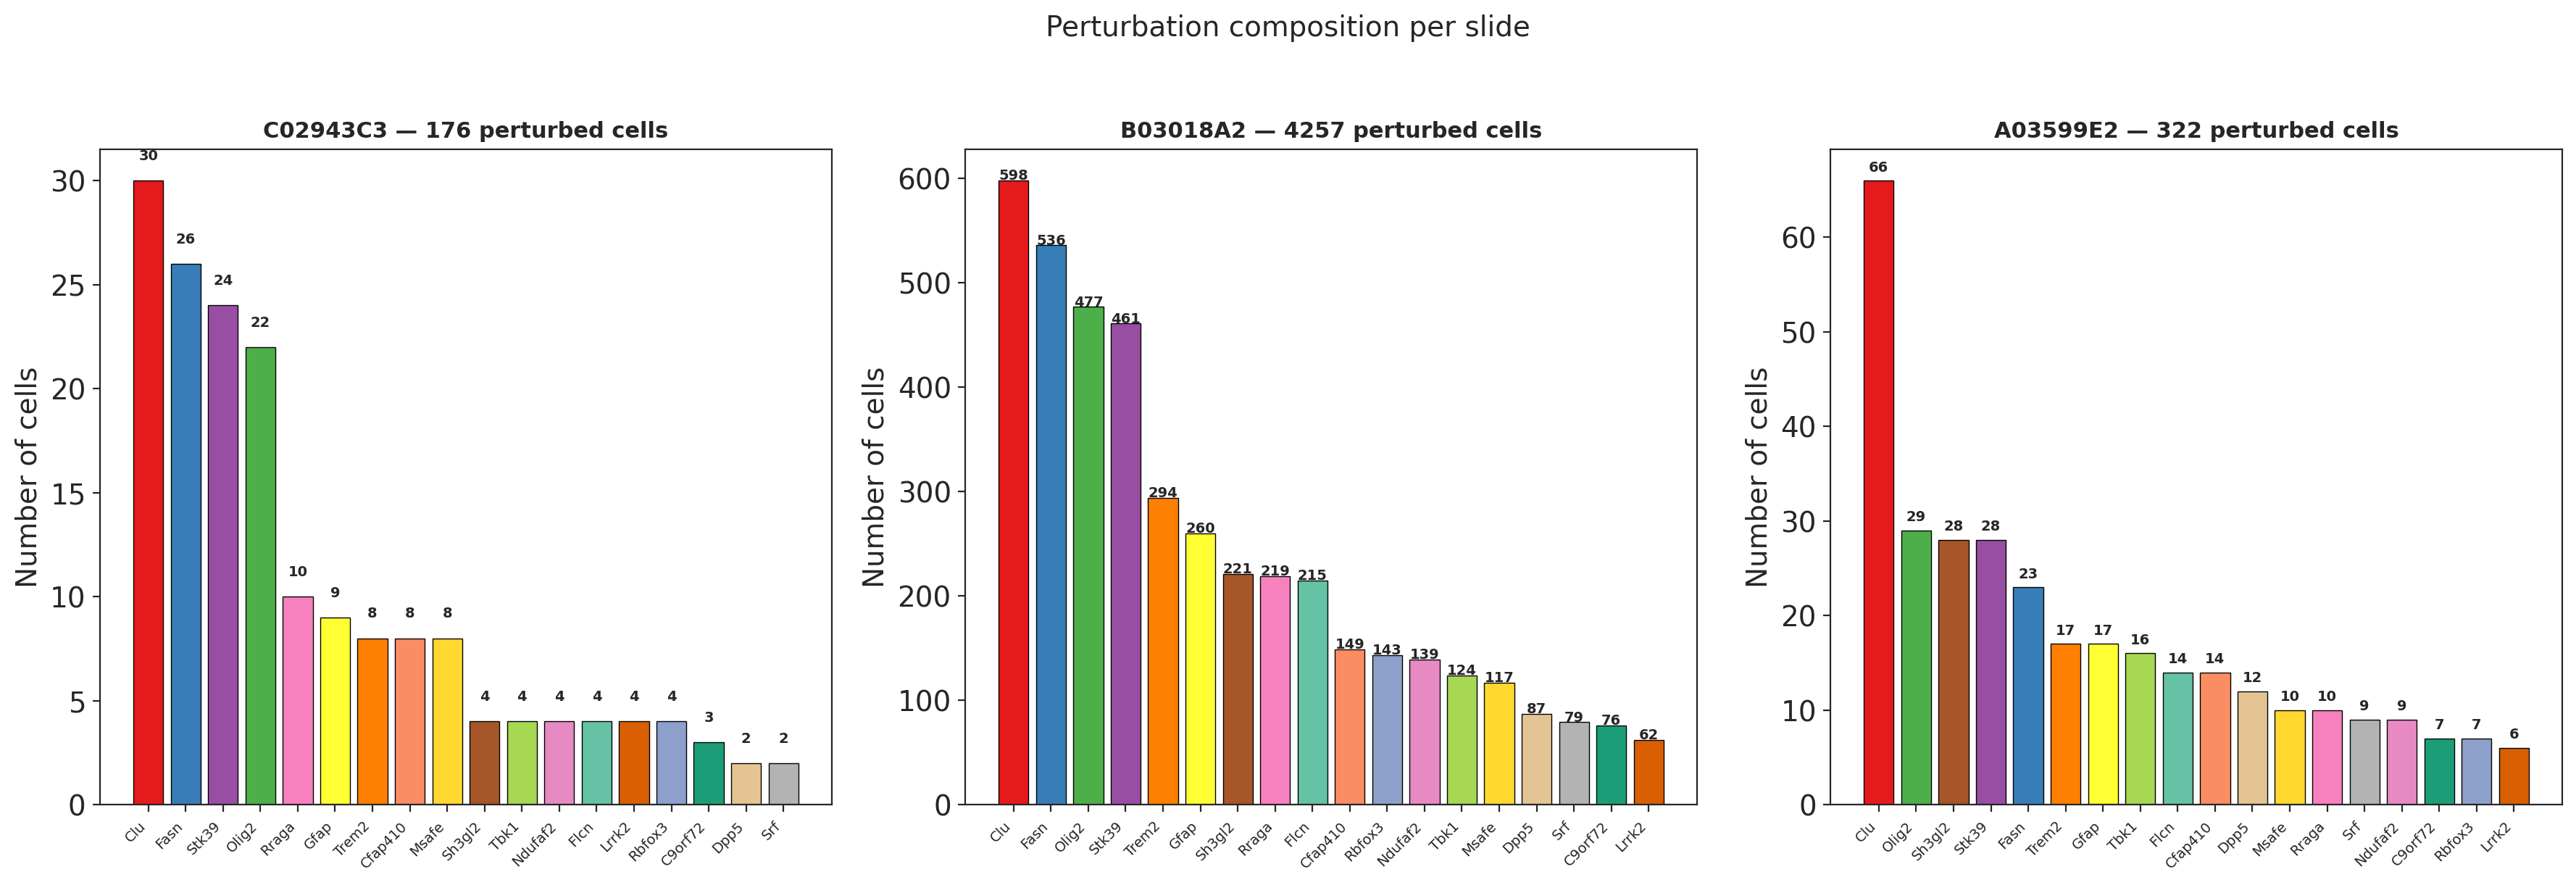

-> perturbation_composition.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, sample in enumerate(SAMPLES):
    ax = axes[i]
    mask = adata.obs["sample"] == sample
    vc = adata.obs["perturbation"][mask].value_counts()
    vc_pert = vc[vc.index != "Neg"]

    colors = [PERT_COLORS.get(p, "#333") for p in vc_pert.index]
    bars = ax.bar(range(len(vc_pert)), vc_pert.values,
                  color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(vc_pert)))
    ax.set_xticklabels(vc_pert.index, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Number of cells")
    ax.set_title(f"{sample} — {vc_pert.sum()} perturbed cells", fontsize=11, fontweight="bold")
    for bar, val in zip(bars, vc_pert.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha="center", fontsize=7, fontweight="bold")

fig.suptitle("Perturbation composition per slide", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "perturbation_composition.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> perturbation_composition.png")


sgRNA genes in panel: 18
  sgrna_gfap
  sgrna_C9orf72
  sgrna_rbfox
  sgrna_rraga
  sgrna_tbk1
  sgrna_clu
  sgrna_oligo2
  sgrna_lrrk2
  sgrna_fasn
  sgrna_flcn
  sgrna_stk39
  sgrna_dpp5
  sgrna_Cfap410
  sgrna_msafe
  sgrna_ndufaf
  sgrna_srf
  sgrna_sh3gl2
  sgrna_trem2


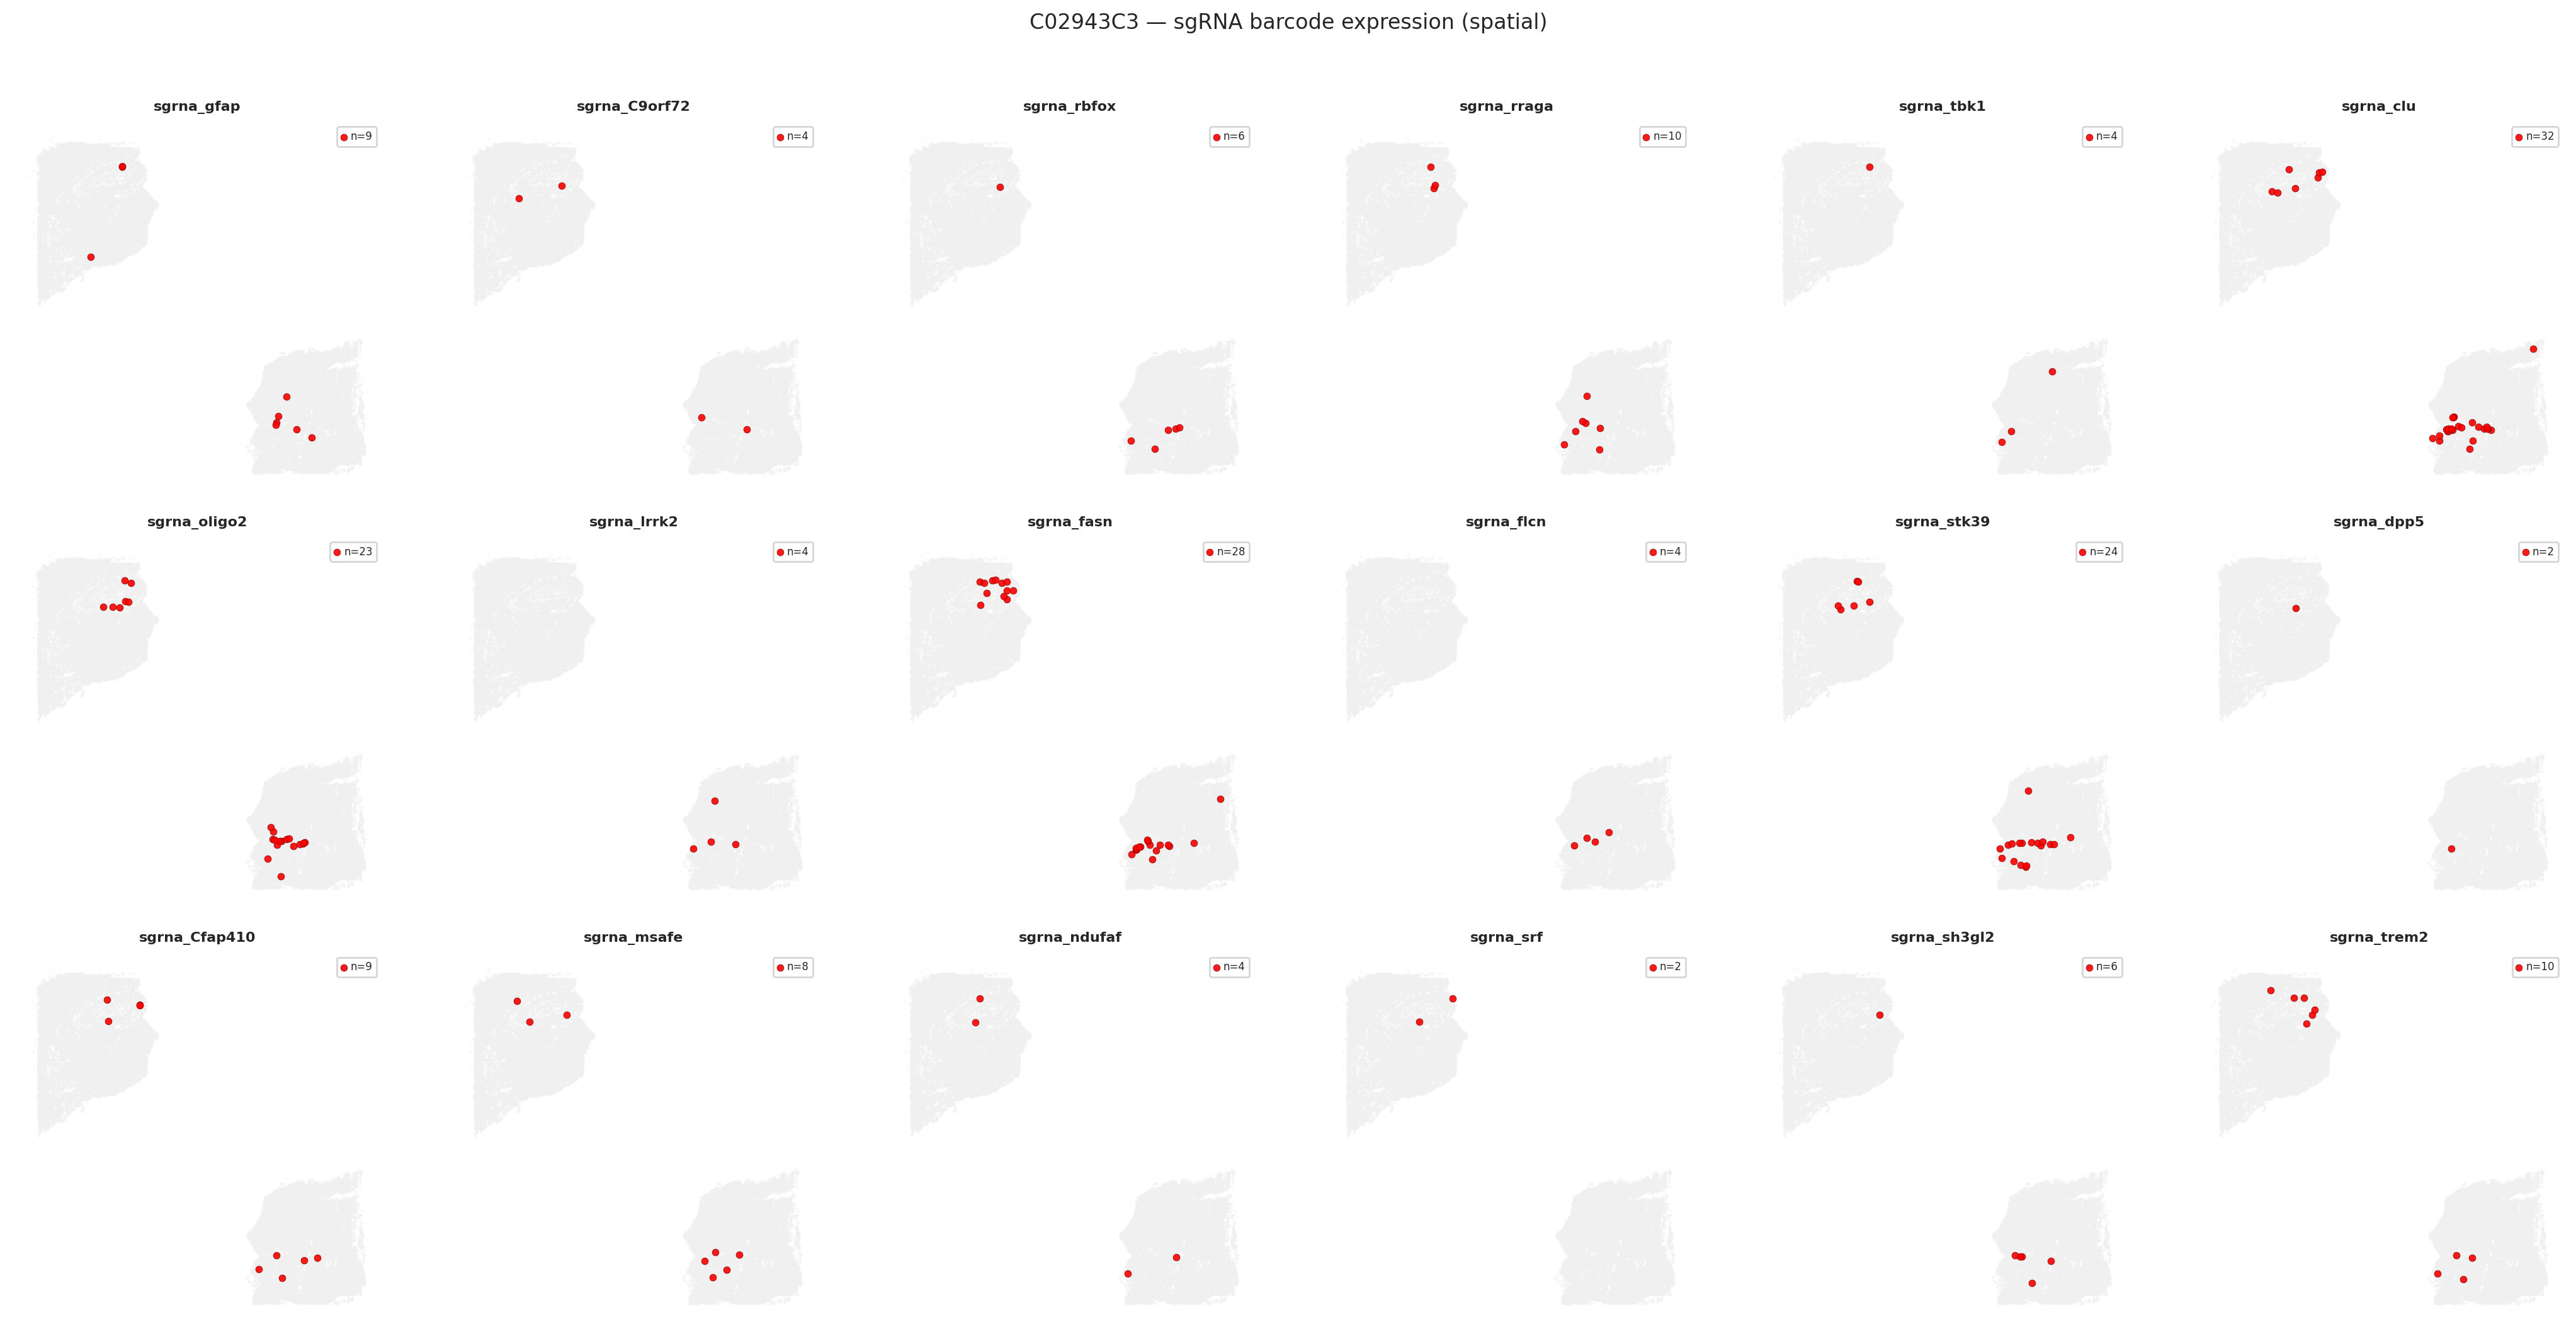

-> sgrna_spatial_C02943C3.png (18 sgRNAs)


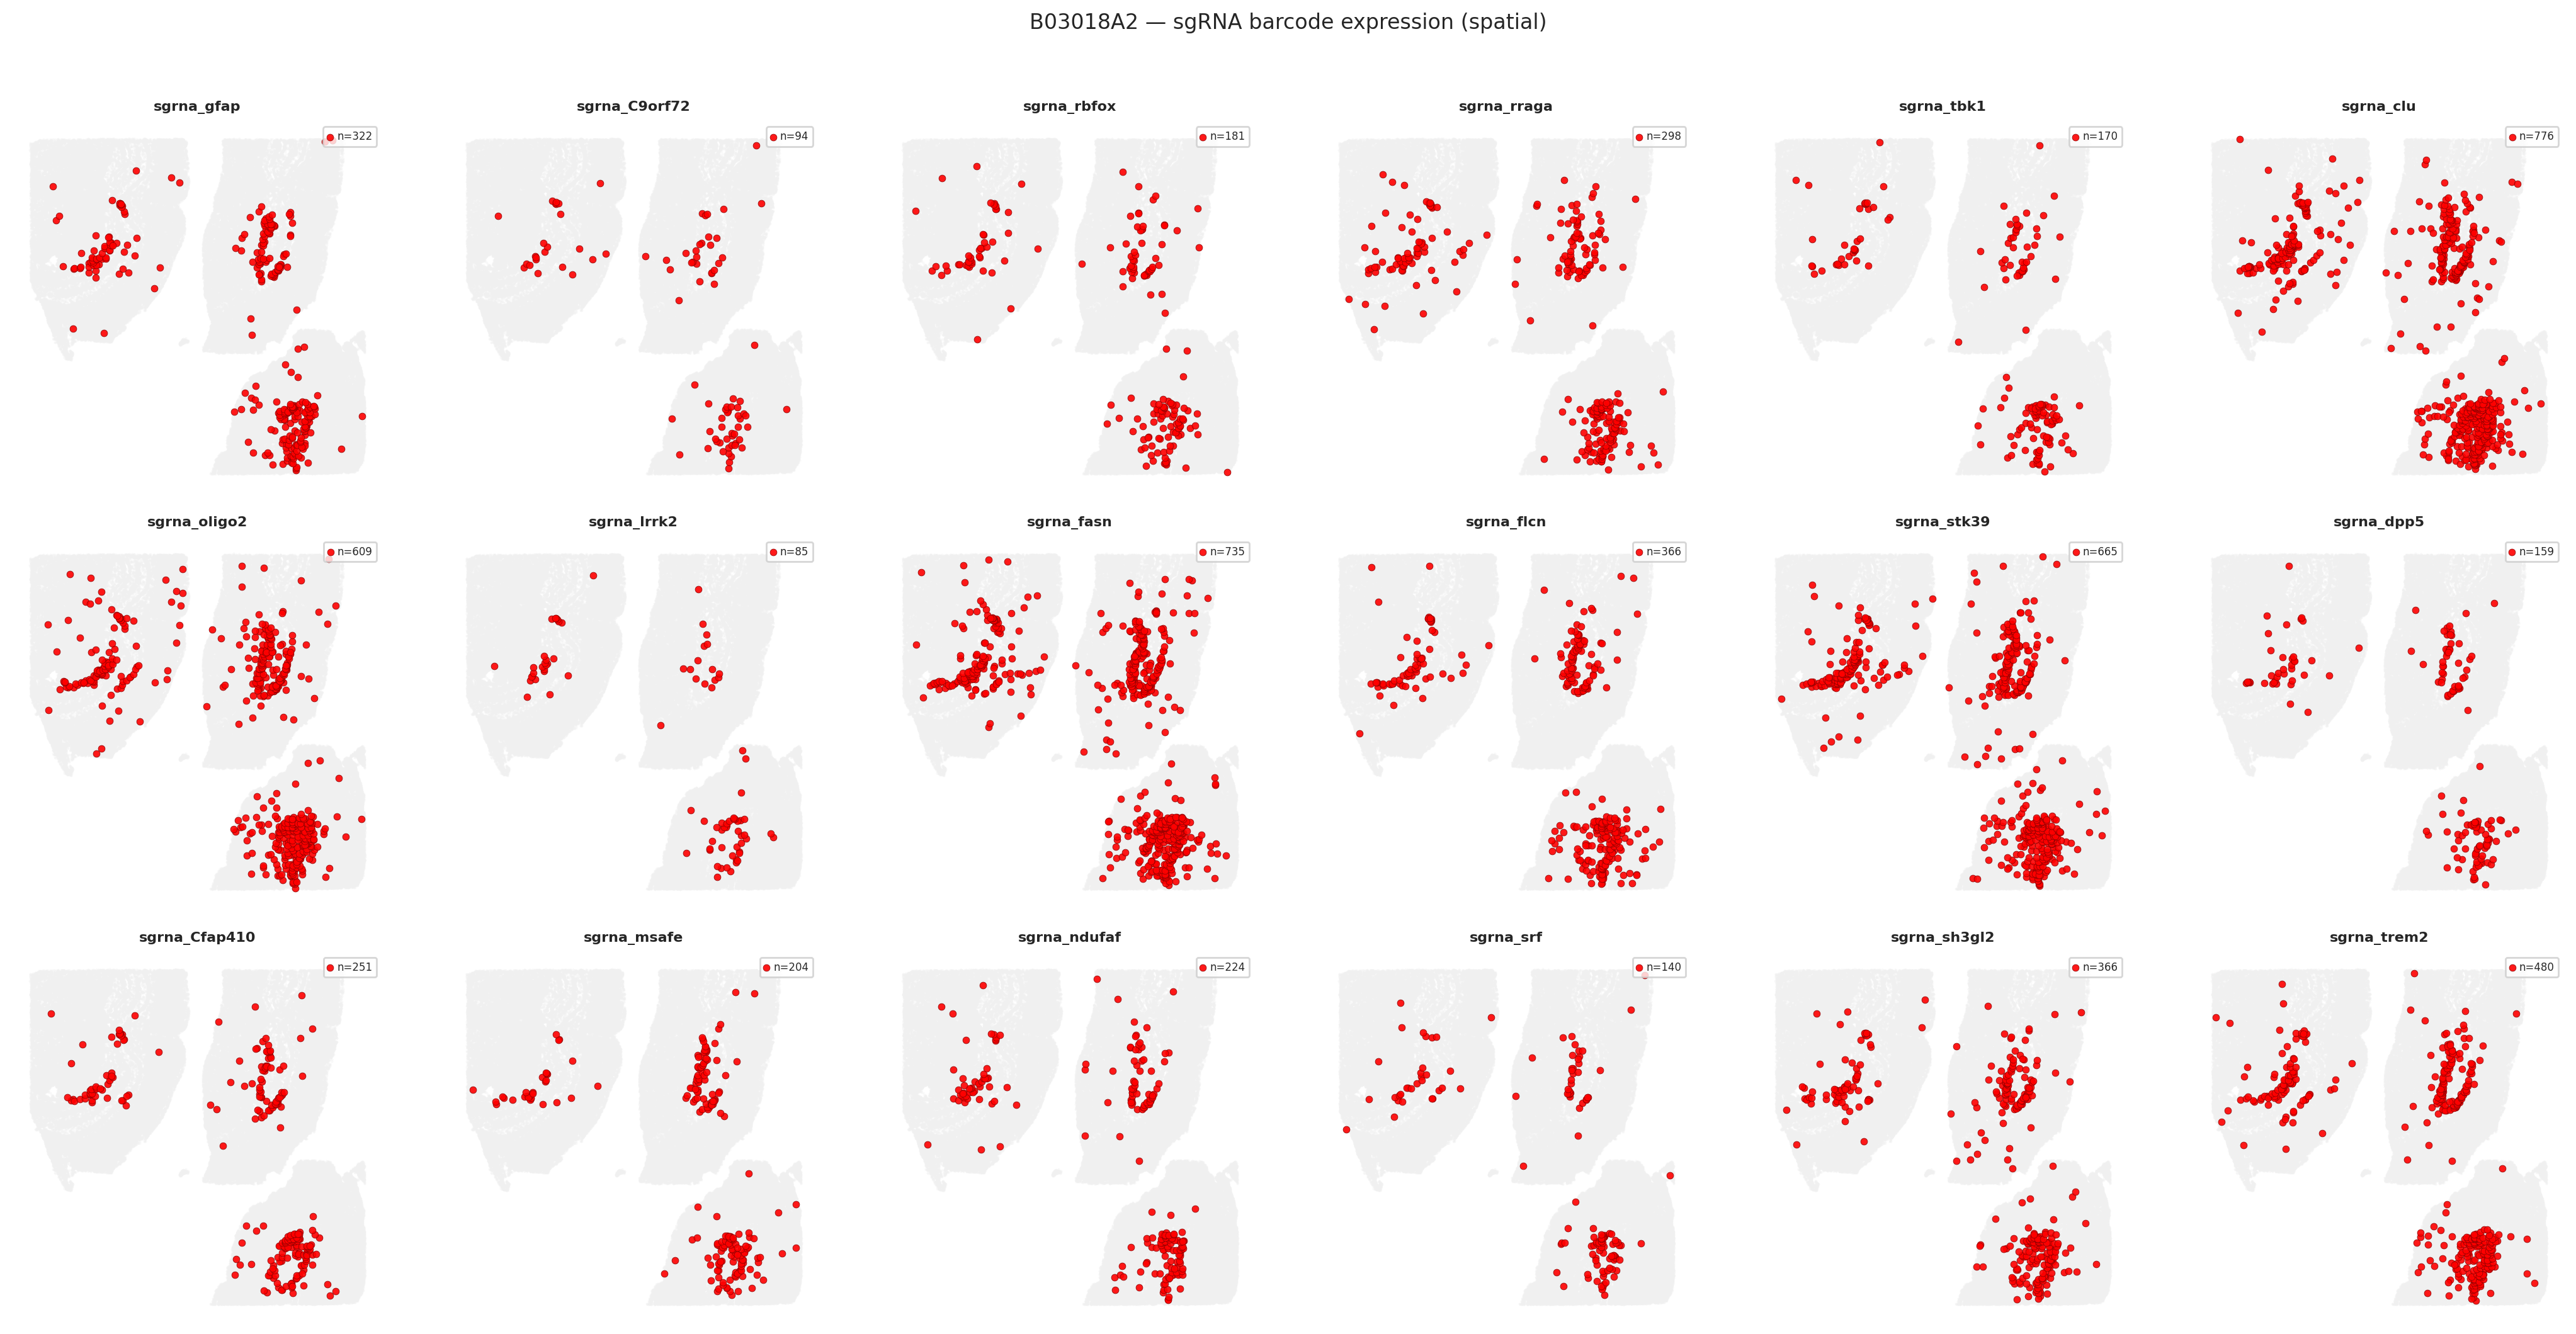

-> sgrna_spatial_B03018A2.png (18 sgRNAs)


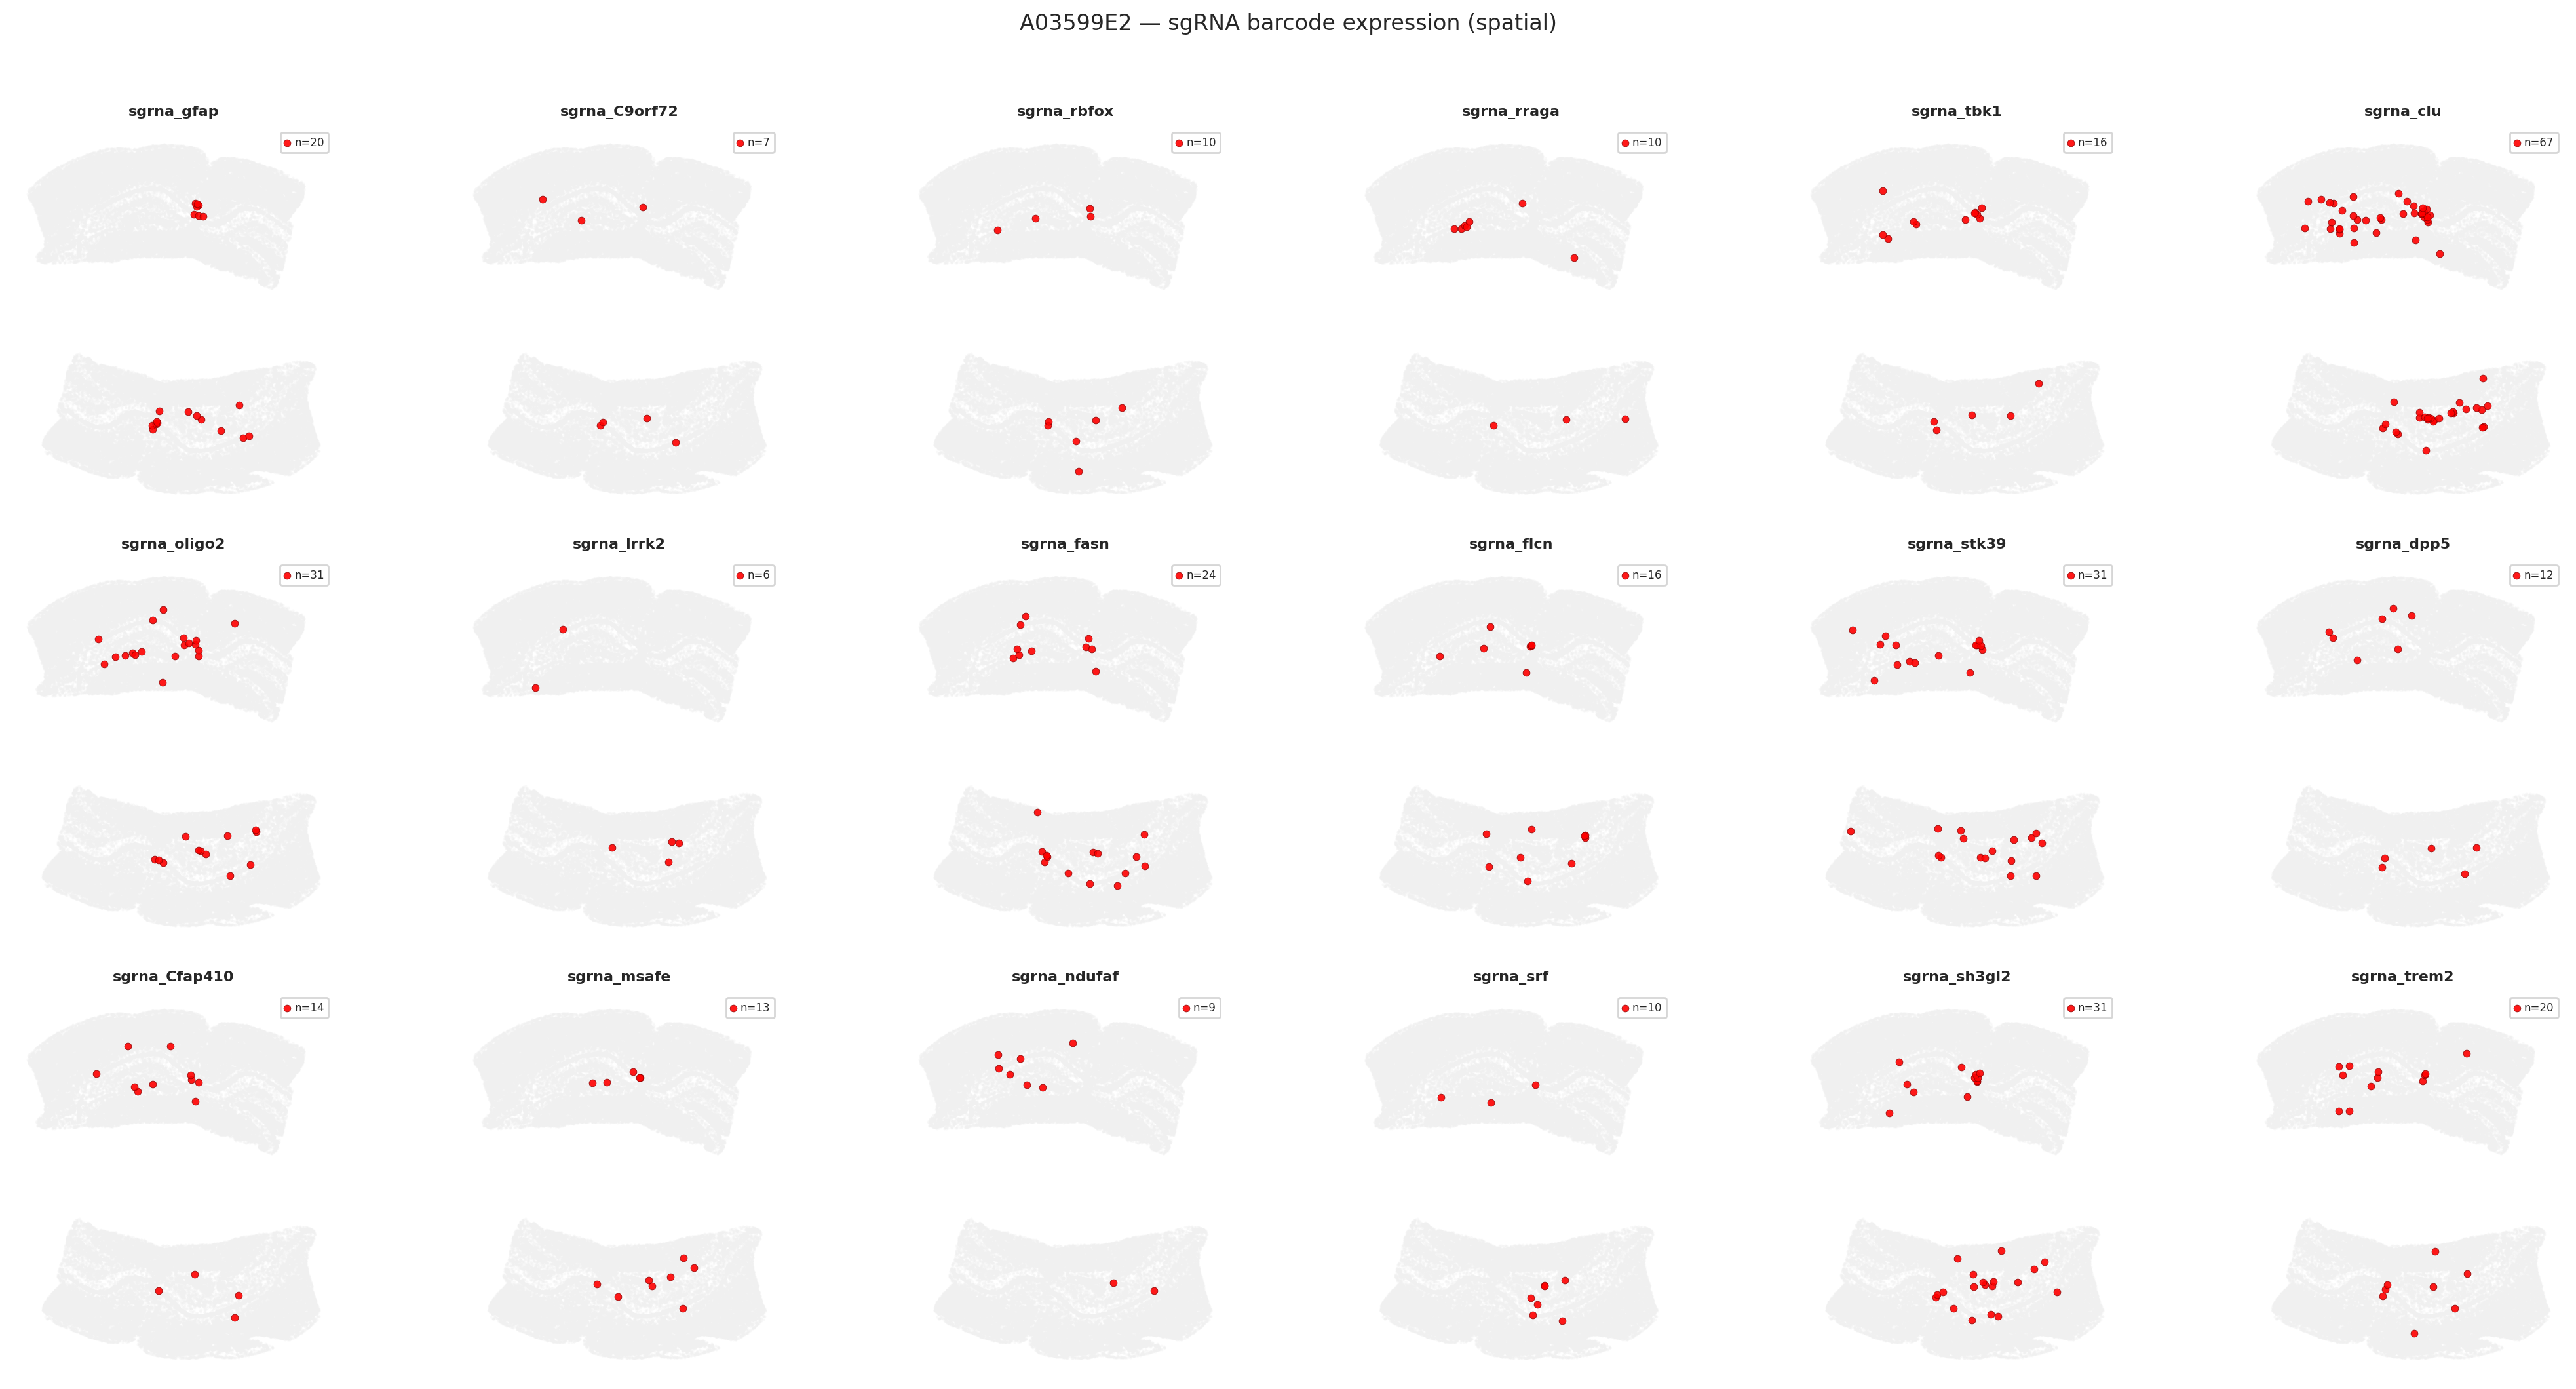

-> sgrna_spatial_A03599E2.png (18 sgRNAs)


In [11]:
sgrna_genes = [g for g in adata.var_names if "sgrna" in g.lower()]
print(f"sgRNA genes in panel: {len(sgrna_genes)}")
for g in sgrna_genes:
    print(f"  {g}")

for sample in SAMPLES:
    mask = adata.obs["sample"] == sample
    sub = adata[mask]
    xy = sub.obsm["spatial"]

    # Get sgRNA expression
    sgrna_idx = [list(sub.var_names).index(g) for g in sgrna_genes]
    sgrna_expr = adata.X[mask][:, sgrna_idx].toarray()

    # Find sgRNAs with expression in this sample
    total_per_sgrna = sgrna_expr.sum(axis=0)
    has_expr = total_per_sgrna > 0
    n_active = has_expr.sum()

    if n_active == 0:
        print(f"\n{sample}: no sgRNA detected")
        continue

    active_genes = [sgrna_genes[j] for j in range(len(sgrna_genes)) if has_expr[j]]
    active_expr = sgrna_expr[:, has_expr]

    ncols = min(6, n_active)
    nrows = int(np.ceil(n_active / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes_flat = axes.flatten() if n_active > 1 else [axes]

    for j in range(n_active):
        ax = axes_flat[j]
        expr_j = active_expr[:, j]
        pos = expr_j > 0
        ax.scatter(xy[:, 0], xy[:, 1], c="#F0F0F0", s=0.2, alpha=0.4, rasterized=True)
        if pos.sum() > 0:
            ax.scatter(xy[pos, 0], xy[pos, 1], c="red", s=15, alpha=0.9,
                       edgecolors="darkred", linewidth=0.3, rasterized=True,
                       label=f"n={pos.sum()}")
            ax.legend(fontsize=6, loc="upper right")
        ax.set_title(active_genes[j], fontsize=8, fontweight="bold")
        ax.set_aspect("equal")
        ax.axis("off")

    for j in range(n_active, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f"{sample} — sgRNA barcode expression (spatial)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"sgrna_spatial_{sample}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"-> sgrna_spatial_{sample}.png ({n_active} sgRNAs)")


Target genes in panel: 16/16


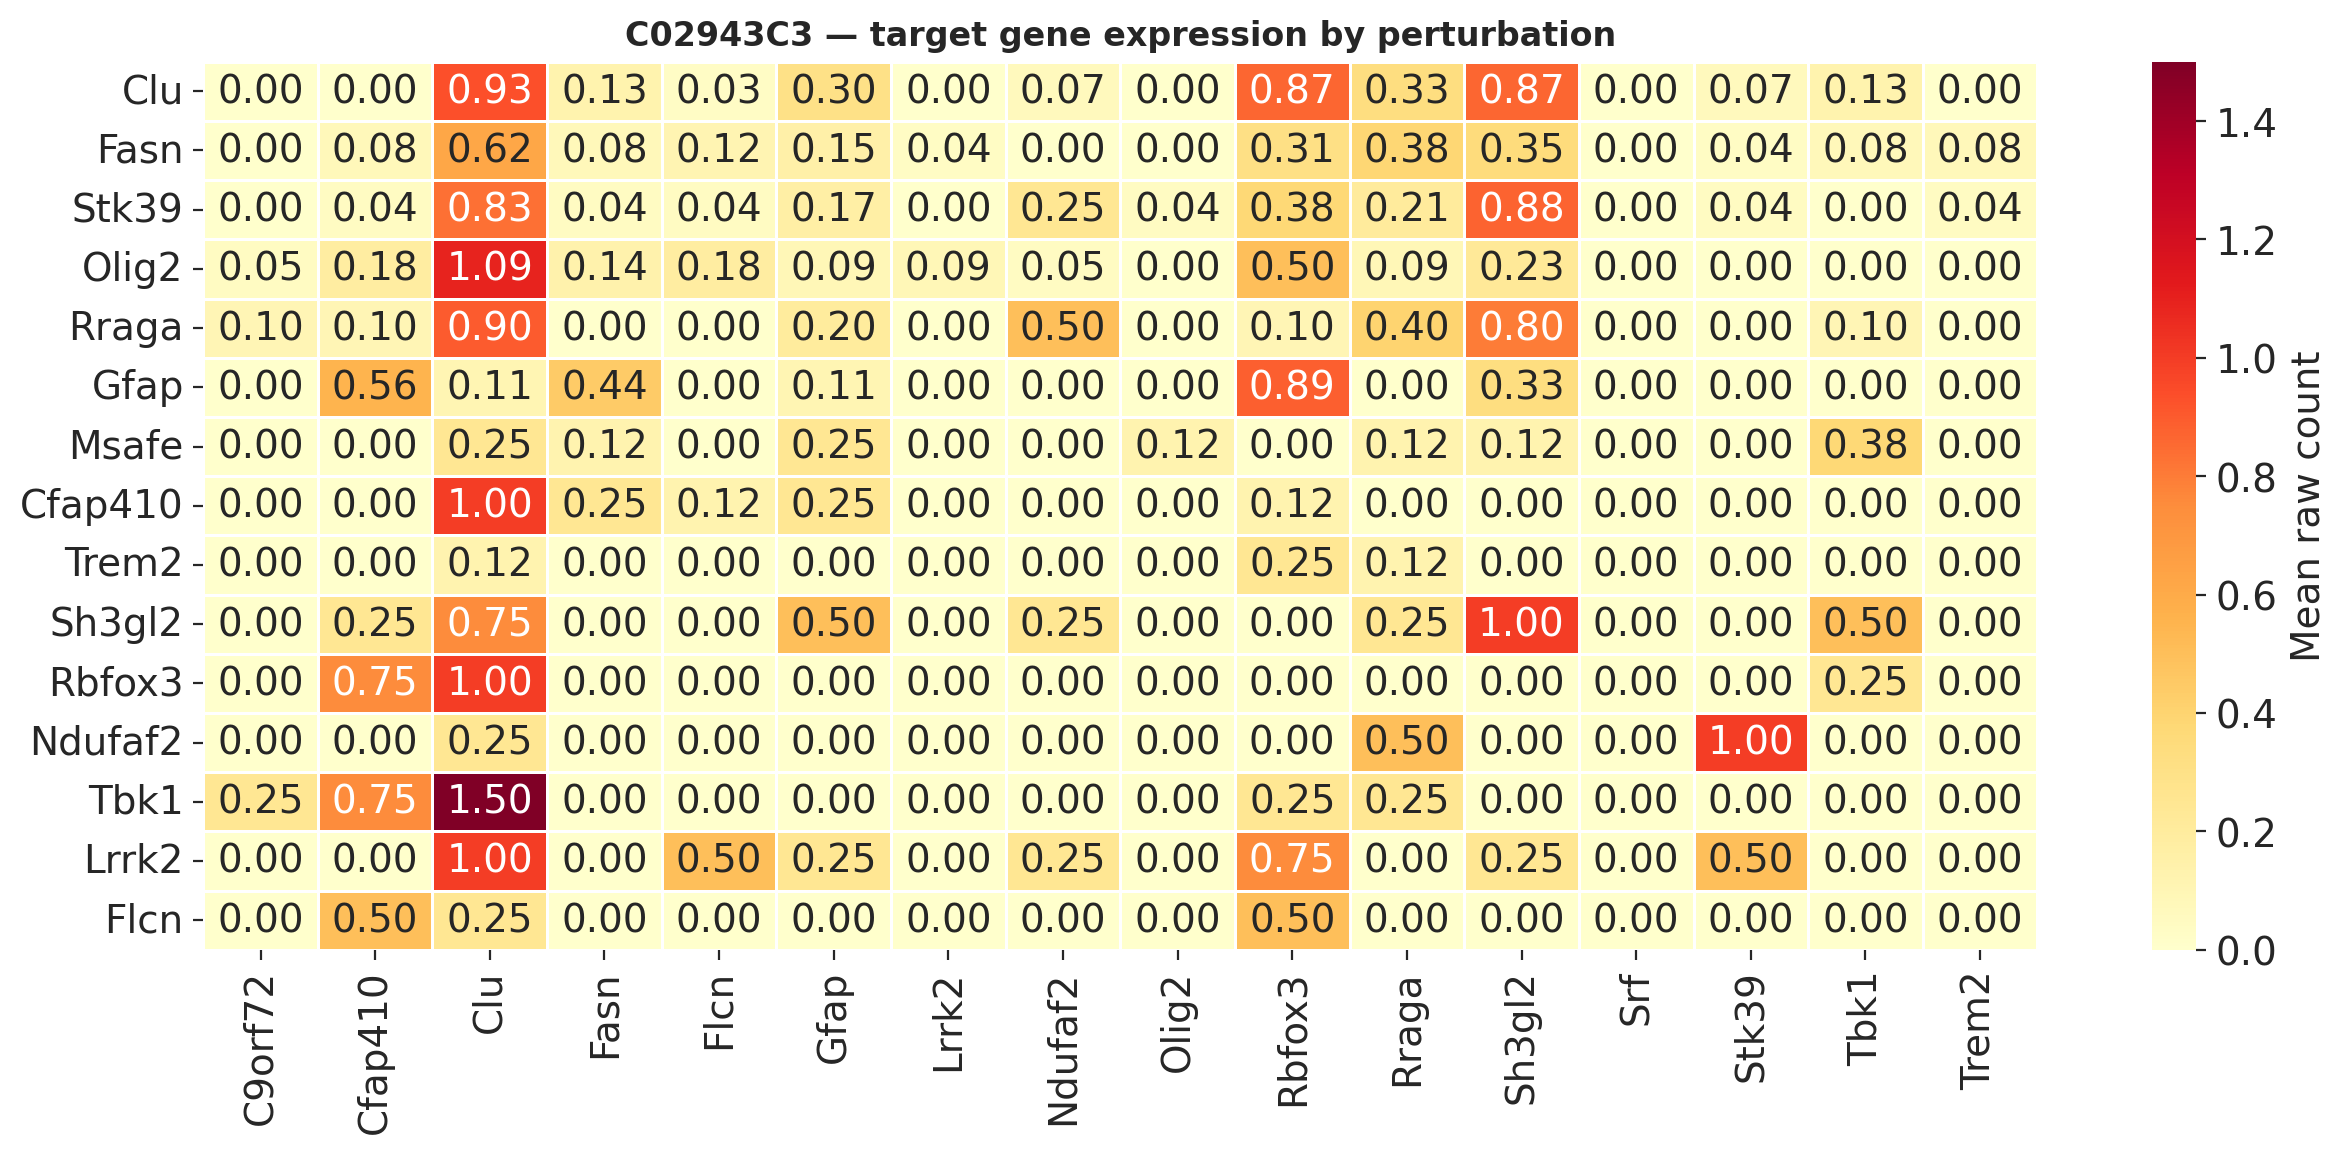

-> target_expr_heatmap_C02943C3.png


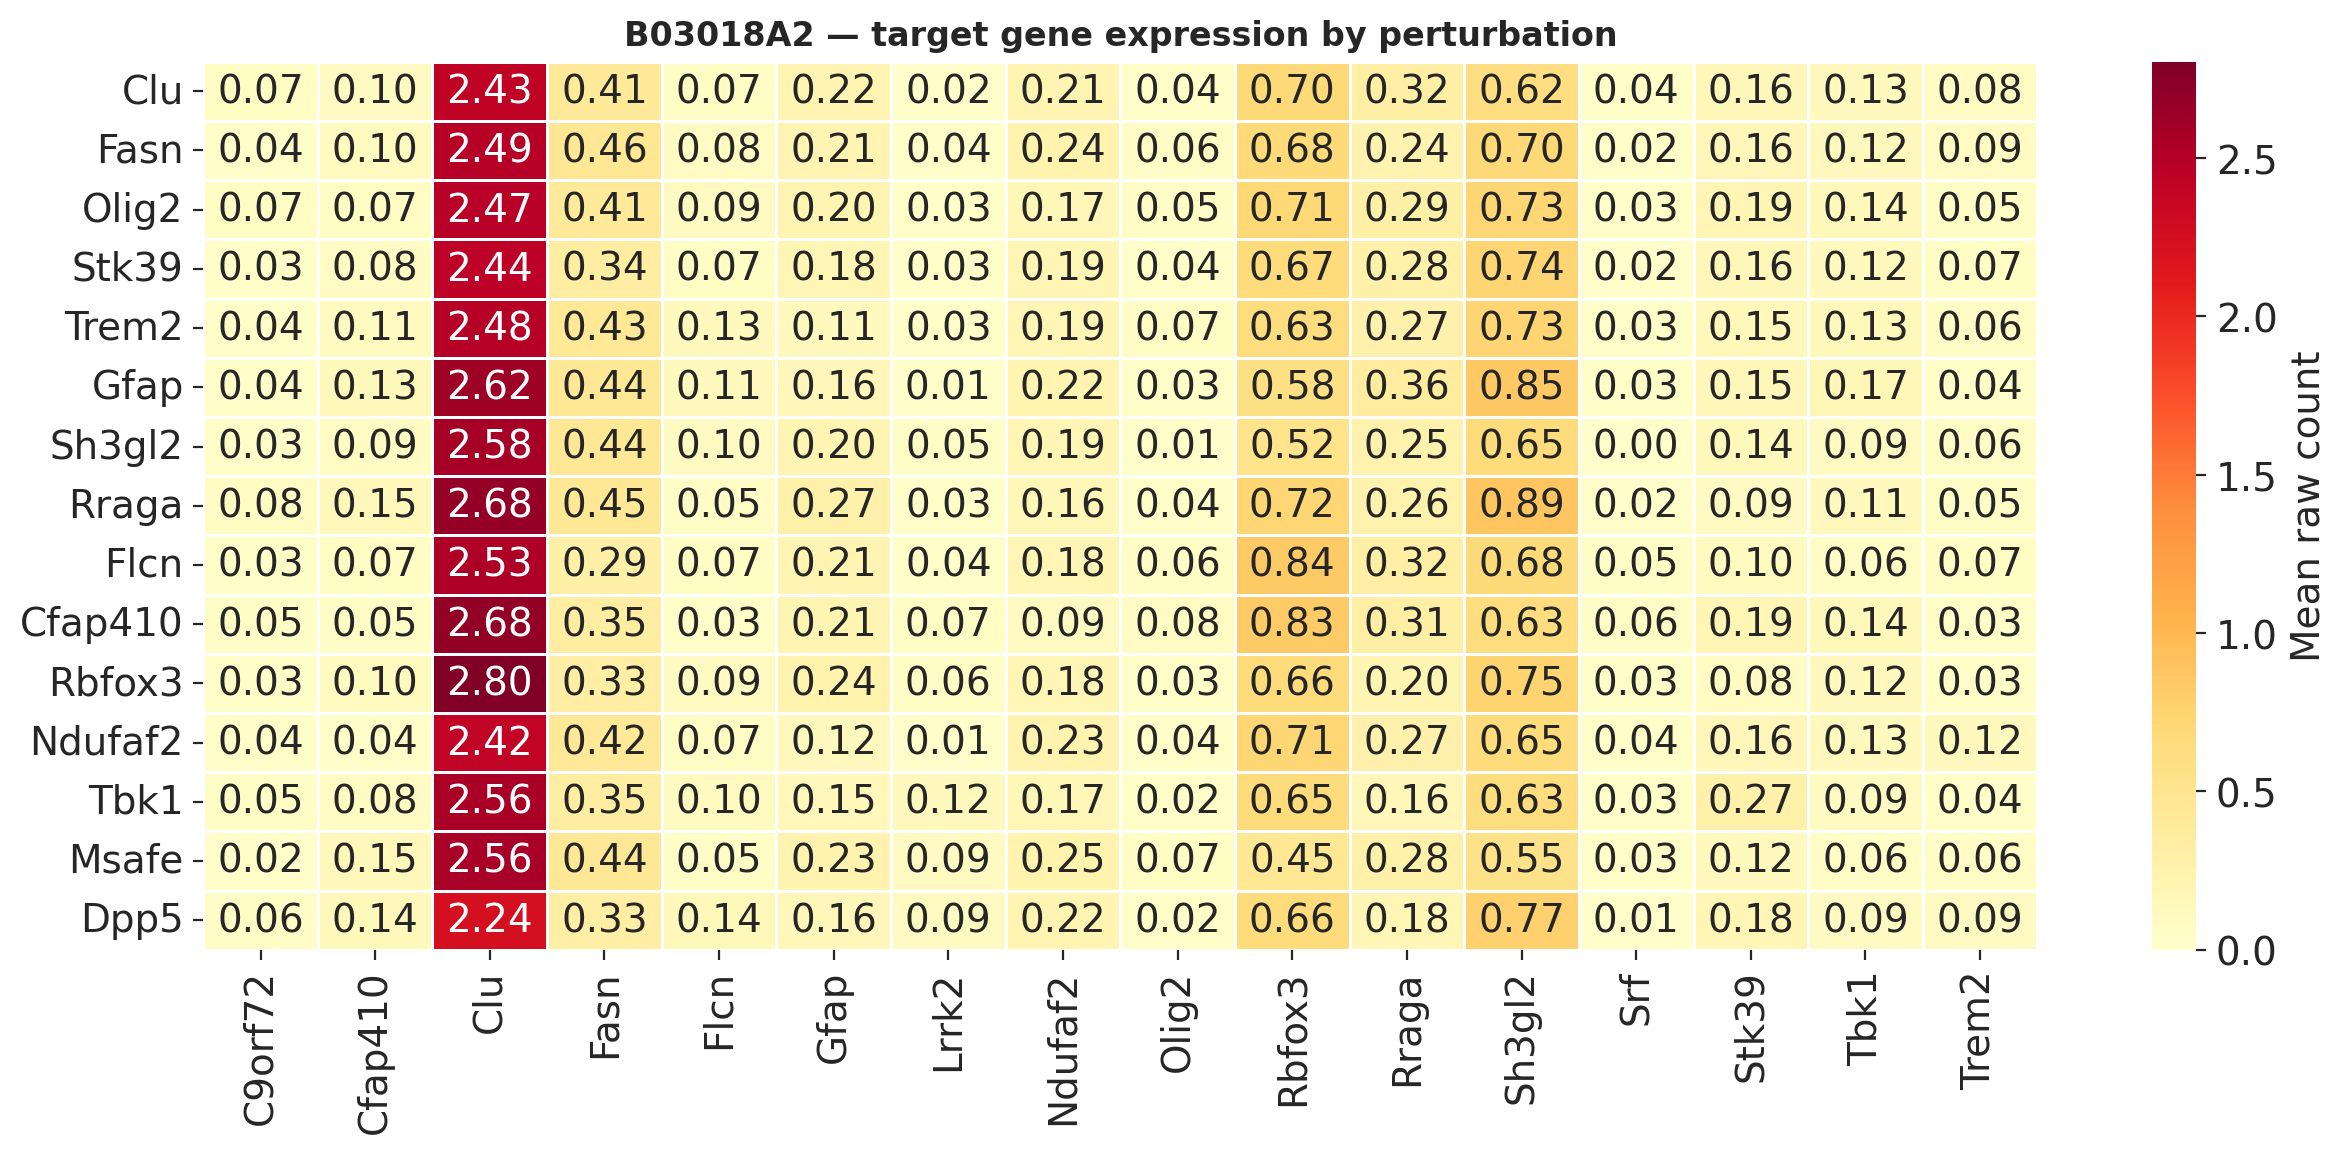

-> target_expr_heatmap_B03018A2.png


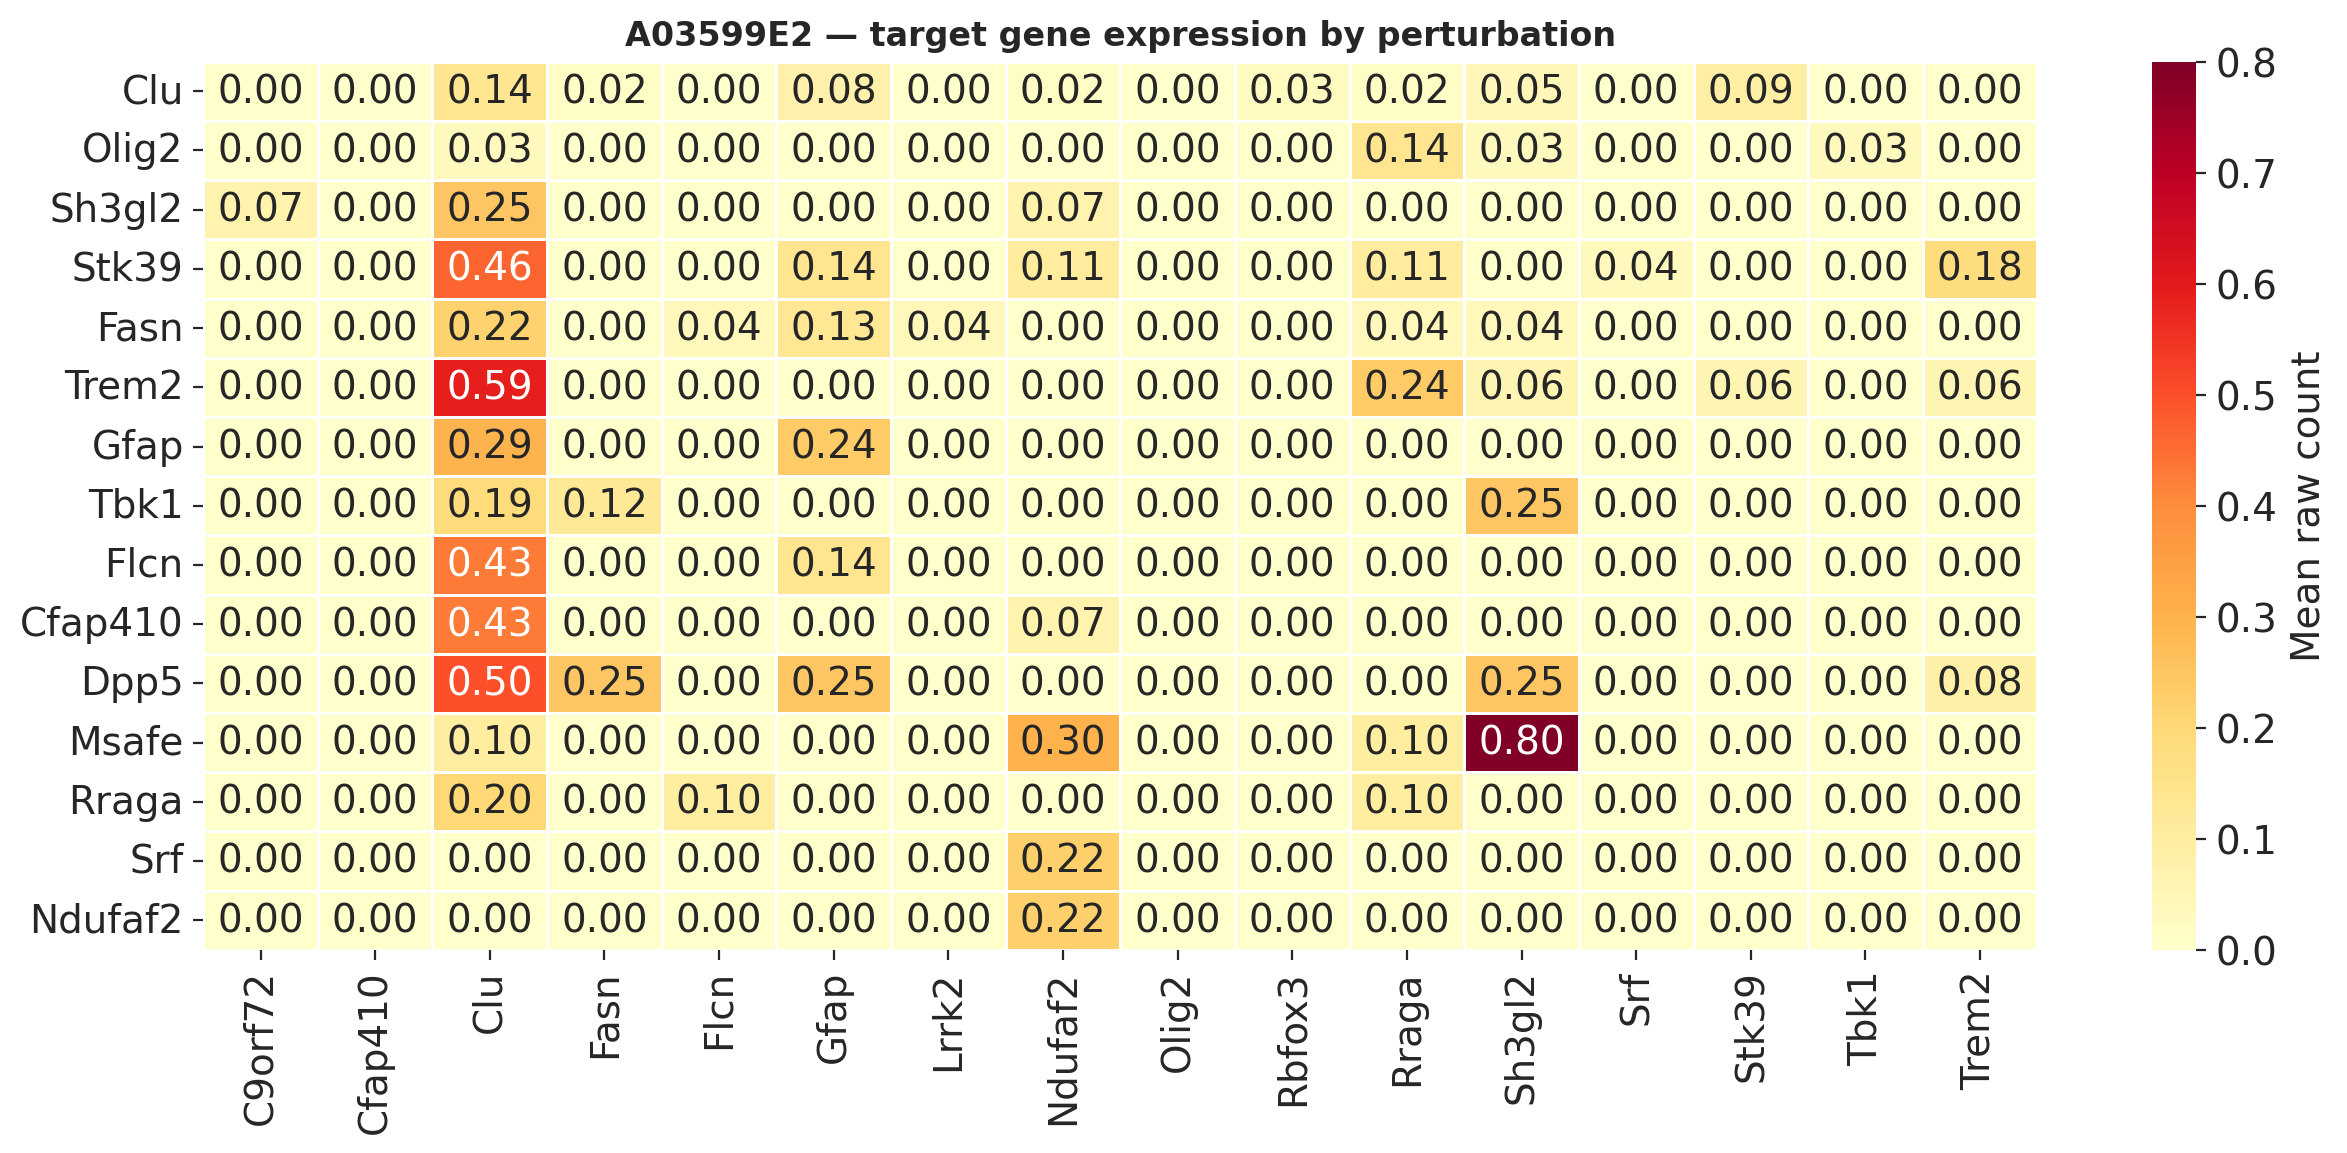

-> target_expr_heatmap_A03599E2.png


In [13]:

# Check expression of the 16 measured target genes in each sample
TARGET_GENES = ["C9orf72", "Cfap410", "Clu", "Fasn", "Flcn", "Gfap", "Lrrk2",
                "Ndufaf2", "Olig2", "Rbfox3", "Rraga", "Sh3gl2", "Srf",
                "Stk39", "Tbk1", "Trem2"]

present_targets = [g for g in TARGET_GENES if g in adata.var_names]
print(f"Target genes in panel: {len(present_targets)}/{len(TARGET_GENES)}")

# Per-sample mean expression of each target gene by perturbation
for sample in SAMPLES:
    mask = adata.obs["sample"] == sample
    sub = adata[mask]
    n_pert_types = len([p for p in sub.obs["perturbation"].unique() if p != "Neg"])

    # Build pseudobulk matrix: perturbation x target gene
    pert_list = sorted(sub.obs["perturbation"].unique(),
                       key=lambda x: (x=="Neg", -((sub.obs["perturbation"]==x).sum())))

    # Build heatmap matrix
    matrix = np.zeros((len(pert_list[:15]), len(present_targets)))
    for i, pert in enumerate(pert_list[:15]):
        p_mask = sub.obs["perturbation"] == pert
        for j, gene in enumerate(present_targets):
            idx = list(sub.var_names).index(gene)
            matrix[i, j] = sub.X[p_mask][:, idx].toarray().mean()

    fig, ax = plt.subplots(figsize=(max(12, len(present_targets)*0.8),
                                    max(4, len(pert_list[:15])*0.4)))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=present_targets, yticklabels=pert_list[:15],
                ax=ax, linewidths=0.5, cbar_kws={"label": "Mean raw count"})
    ax.set_title(f"{sample} — target gene expression by perturbation",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"target_expr_heatmap_{sample}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"-> target_expr_heatmap_{sample}.png")


Analyzing B03018A2: 123921 cells, 4257 perturbed

Perturbation efficiency — B03018A2:
   gene  n_pert  mean_pert  mean_neg  median_pert  median_neg  pct_pert  pct_neg       fc
C9orf72      76   0.026316    0.0270          0.0         0.0  2.631579     2.35 0.974658
Cfap410     149   0.053691    0.0590          0.0         0.0  5.369128     4.50 0.910021
    Clu     598   2.428094    1.7325          2.0         1.0 76.755853    61.55 1.401497
   Fasn     536   0.464552    0.2340          0.0         0.0 28.171642    15.35 1.985266
   Flcn     215   0.074419    0.0645          0.0         0.0  6.046512     4.95 1.153777
   Gfap     260   0.161538    0.1805          0.0         0.0 10.384615    11.35 0.894950
  Lrrk2      62   0.048387    0.0350          0.0         0.0  3.225806     2.60 1.382488
Ndufaf2     139   0.230216    0.1255          0.0         0.0 15.827338     8.95 1.834389
  Olig2     477   0.054507    0.0470          0.0         0.0  3.983229     3.55 1.159730
 Rbfox3     14

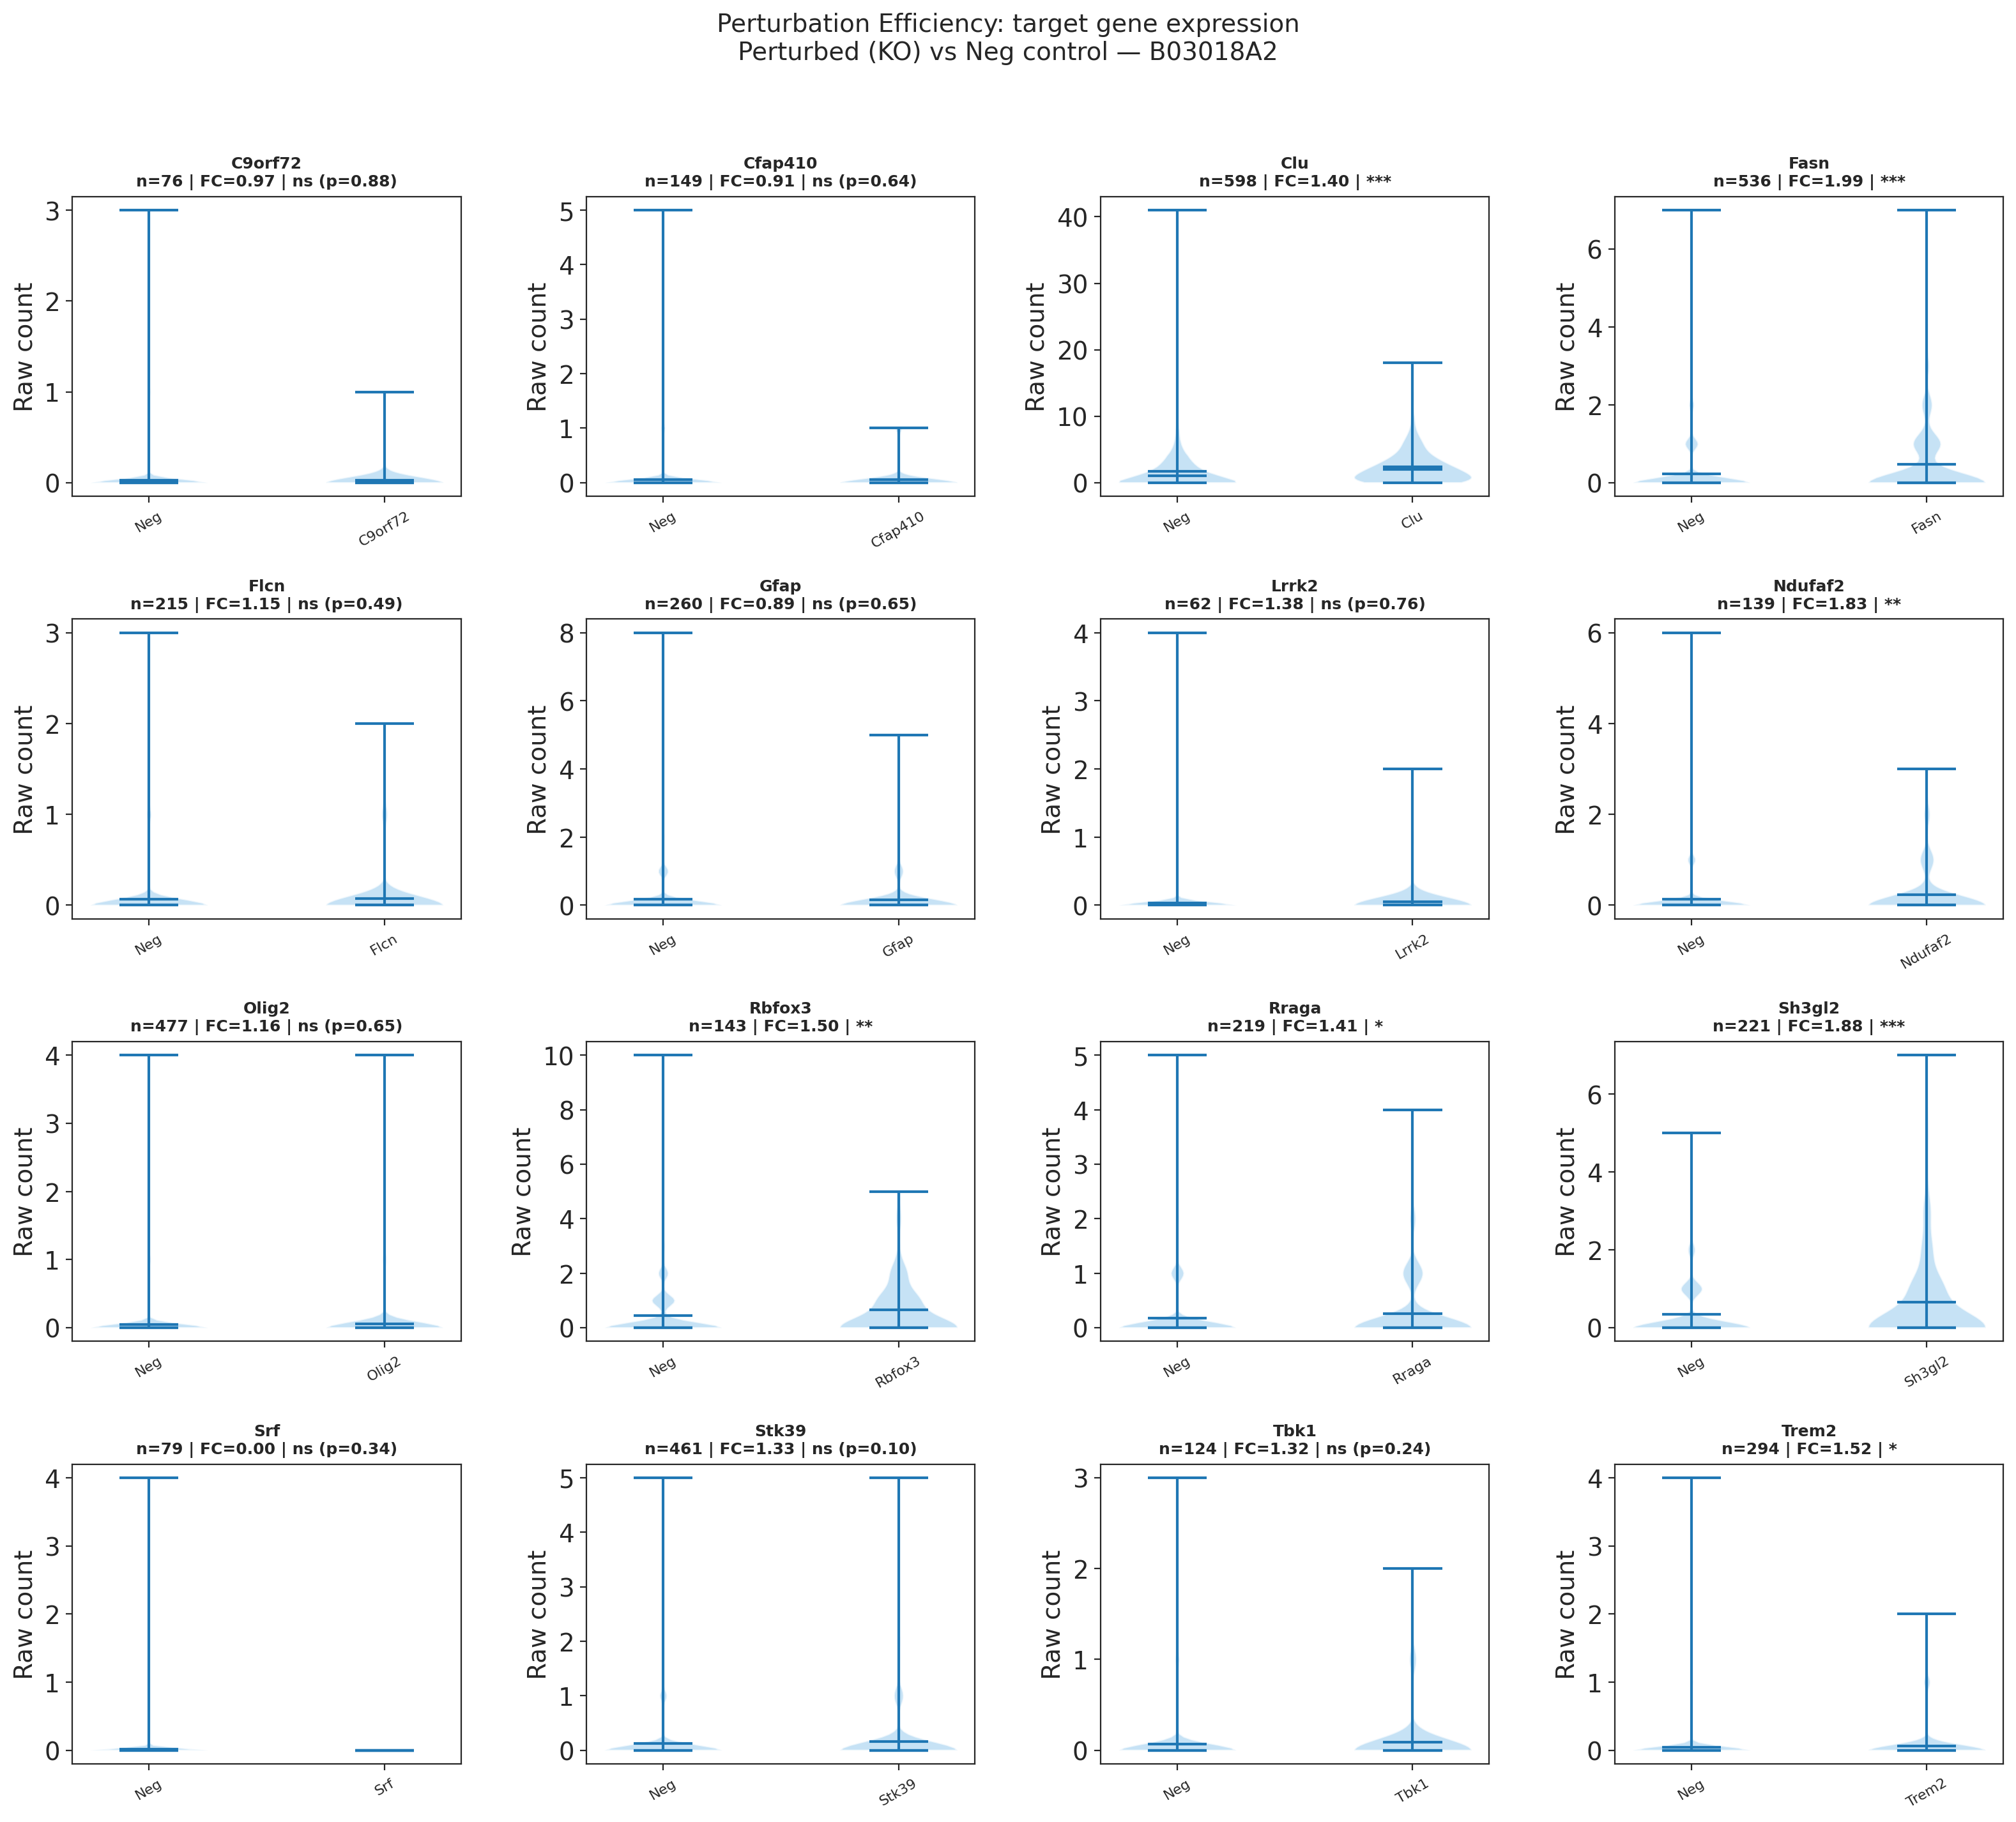


-> perturbation_efficiency_B03018A2.png


In [15]:

# Key analysis: for each perturbed gene, check its expression in cells carrying its sgRNA
# This measures perturbation efficiency — does the CRISPR KO reduce target gene expression?

# Map sgRNA → target gene
sgRNA_to_target = {
    "sgrna_gfap": "Gfap", "sgrna_C9orf72": "C9orf72", "sgrna_rbfox": "Rbfox3",
    "sgrna_rraga": "Rraga", "sgrna_tbk1": "Tbk1", "sgrna_clu": "Clu",
    "sgrna_oligo2": "Olig2", "sgrna_lrrk2": "Lrrk2", "sgrna_fasn": "Fasn",
    "sgrna_flcn": "Flcn", "sgrna_stk39": "Stk39", "sgrna_dpp5": "Dpp5",
    "sgrna_Cfap410": "Cfap410", "sgrna_msafe": "Msafe", "sgrna_ndufaf": "Ndufaf2",
    "sgrna_srf": "Srf", "sgrna_sh3gl2": "Sh3gl2", "sgrna_trem2": "Trem2",
}

# Focus on B03018A2 (largest sample, most perturbed cells)
sample = "B03018A2"
mask = adata.obs["sample"] == sample
sub = adata[mask]
print(f"Analyzing {sample}: {sub.n_obs} cells, {(sub.obs['perturbation']!='Neg').sum()} perturbed")

# Get the perturbation and sgRNA info
pert_labels = sub.obs["perturbation"].values
sgRNA_labels = sub.obs["sgRNA"].values

# For each target gene present in panel, compare perturbed vs Neg
TARGET_GENES = ["C9orf72", "Cfap410", "Clu", "Fasn", "Flcn", "Gfap", "Lrrk2",
                "Ndufaf2", "Olig2", "Rbfox3", "Rraga", "Sh3gl2", "Srf",
                "Stk39", "Tbk1", "Trem2"]

present = [g for g in TARGET_GENES if g in sub.var_names]

# Build comparison dataframe
records = []
for target in present:
    # Cells perturbed with this target's sgRNA
    pert_cells = pert_labels == target
    # Neg control cells
    neg_cells = pert_labels == "Neg"
    
    if pert_cells.sum() == 0:
        continue
    
    idx = list(sub.var_names).index(target)
    expr_pert = sub.X[pert_cells, idx].toarray().flatten()
    expr_neg = sub.X[neg_cells, idx].toarray().flatten()
    
    # Downsample Neg for fair comparison
    if len(expr_neg) > 2000:
        rng = np.random.RandomState(42)
        expr_neg = rng.choice(expr_neg, 2000, replace=False)
    
    records.append({
        "gene": target,
        "n_pert": pert_cells.sum(),
        "mean_pert": expr_pert.mean(),
        "mean_neg": expr_neg.mean(),
        "median_pert": np.median(expr_pert),
        "median_neg": np.median(expr_neg),
        "pct_pert": 100 * (expr_pert > 0).mean(),
        "pct_neg": 100 * (expr_neg > 0).mean(),
        "fc": expr_pert.mean() / (expr_neg.mean() + 1e-8),
    })

df_eff = pd.DataFrame(records).sort_values("gene")
print(f"\nPerturbation efficiency — {sample}:")
print(df_eff.to_string(index=False))

# Plot: perturbed vs Neg expression for each target gene
n_genes = len(df_eff)
ncols = 4
nrows = int(np.ceil(n_genes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes_flat = axes.flatten() if n_genes > 1 else [axes]

for i, (_, row) in enumerate(df_eff.iterrows()):
    ax = axes_flat[i]
    gene = row["gene"]
    idx = list(sub.var_names).index(gene)
    
    pert_cells = pert_labels == gene
    neg_cells = pert_labels == "Neg"
    
    expr_pert = sub.X[pert_cells, idx].toarray().flatten()
    expr_neg = sub.X[neg_cells, idx].toarray().flatten()
    rng = np.random.RandomState(42)
    if len(expr_neg) > 2000:
        expr_neg = rng.choice(expr_neg, 2000, replace=False)
    
    parts = ax.violinplot([expr_neg, expr_pert], positions=[0, 1],
                          showmeans=True, showmedians=True)
    for pc in parts["bodies"]:
        pc.set_facecolor("#AED6F1")
        pc.set_alpha(0.7)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Neg", gene], rotation=30, fontsize=8)
    ax.set_ylabel("Raw count")
    
    # Mann-Whitney test
    from scipy.stats import mannwhitneyu
    try:
        stat, pval = mannwhitneyu(expr_pert, expr_neg, alternative="two-sided")
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else f"ns (p={pval:.2f})"
    except:
        sig = ""
    
    ax.set_title(f"{gene}\nn={row['n_pert']} | FC={row['fc']:.2f} | {sig}",
                 fontsize=9, fontweight="bold")

for j in range(n_genes, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f"Perturbation Efficiency: target gene expression\nPerturbed (KO) vs Neg control — {sample}",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"perturbation_efficiency_{sample}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n-> perturbation_efficiency_{sample}.png")


Cross-sample perturbation efficiency


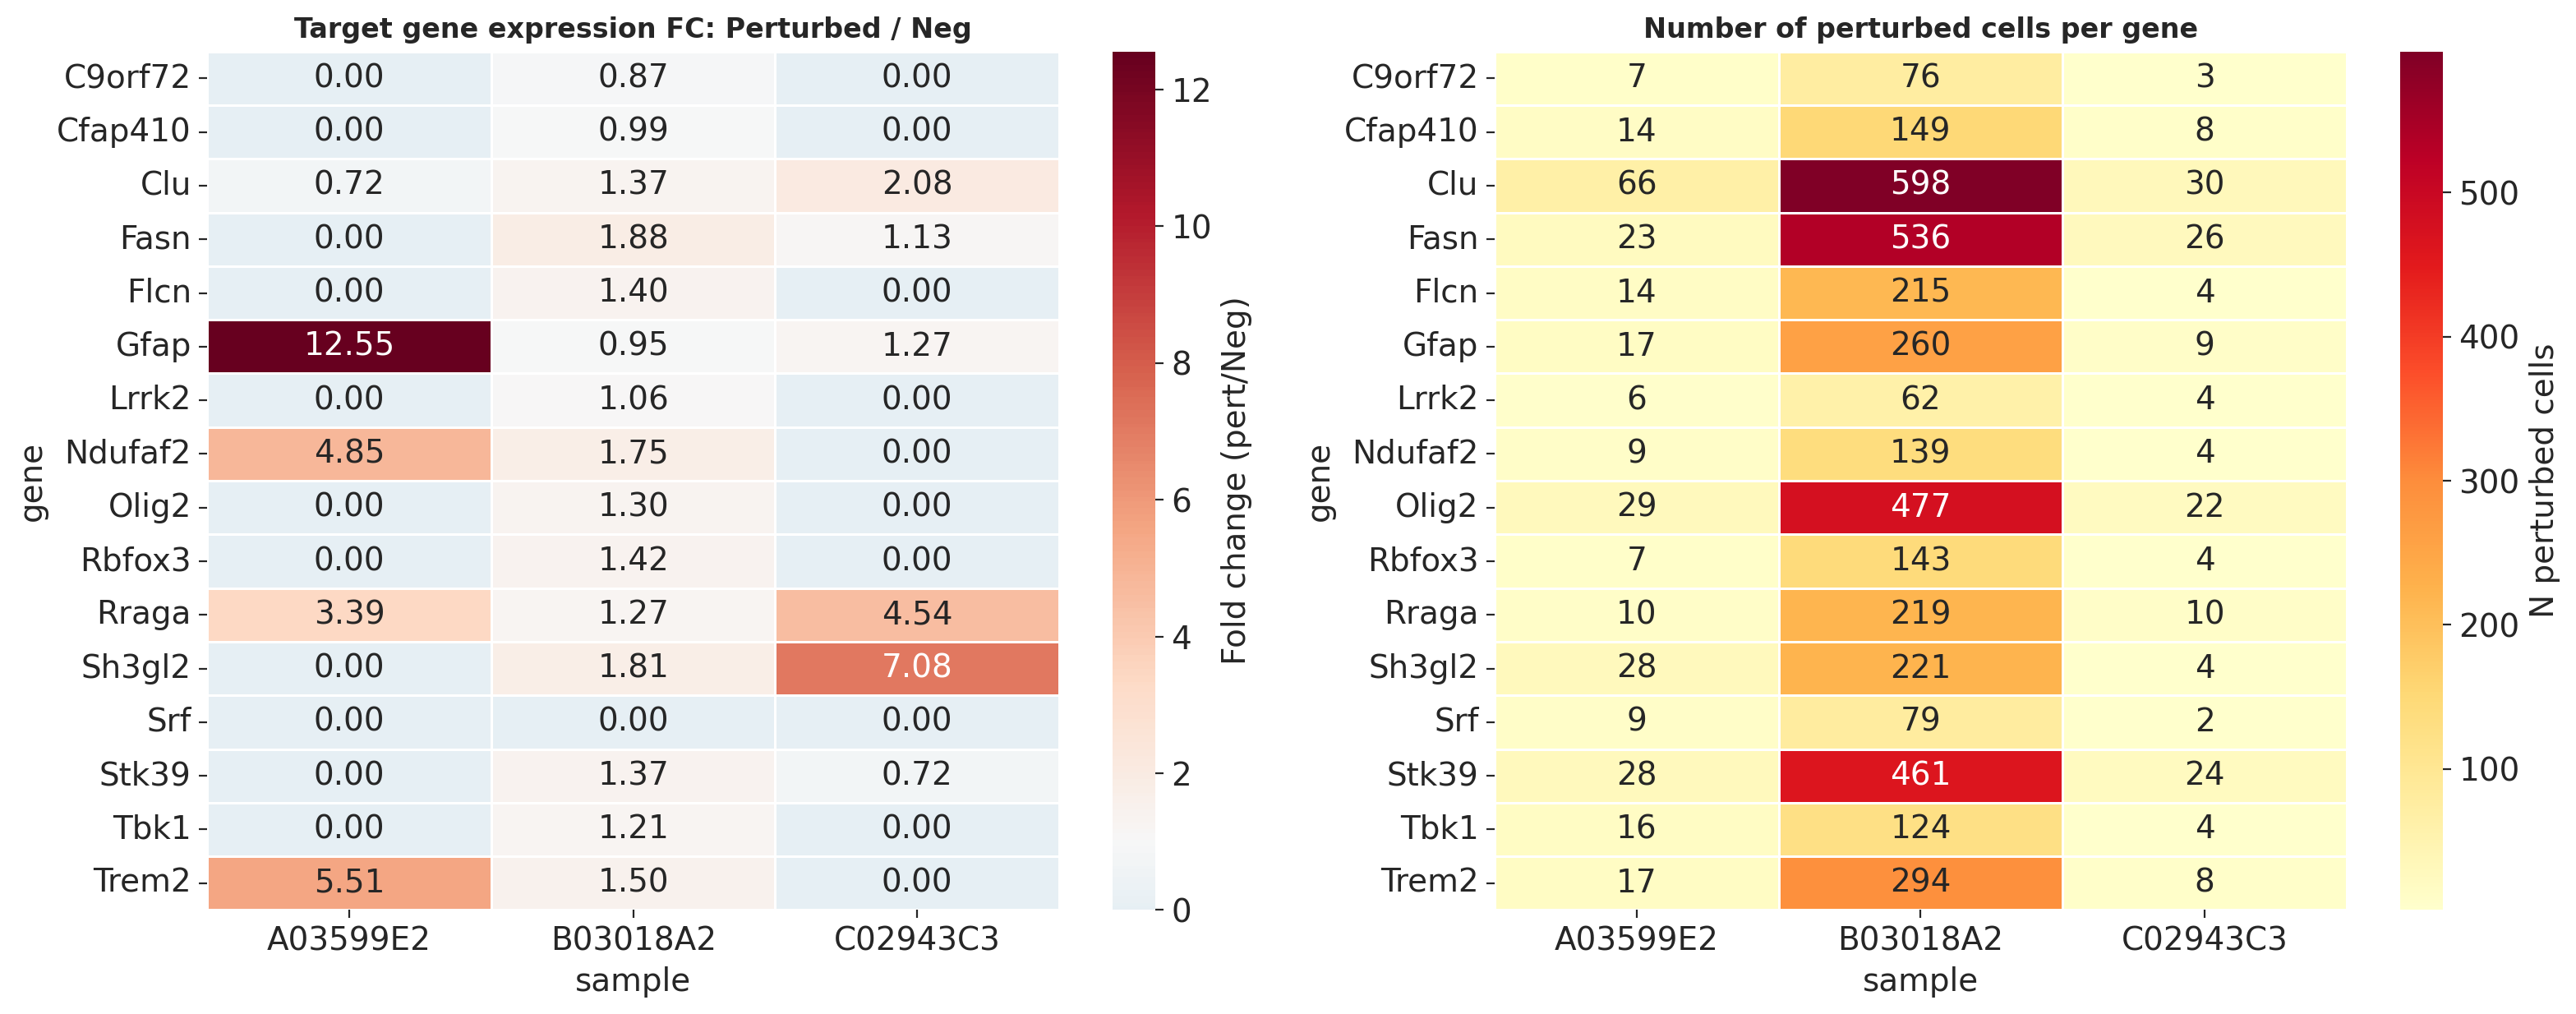

-> cross_sample_perturbation_efficiency.png

Perturbation efficiency (FC = mean_perturbed / mean_Neg):
sample   A03599E2  B03018A2  C02943C3
gene                                 
C9orf72     0.000     0.866     0.000
Cfap410     0.000     0.990     0.000
Clu         0.719     1.372     2.081
Fasn        0.000     1.880     1.132
Flcn        0.000     1.396     0.000
Gfap       12.552     0.949     1.271
Lrrk2       0.000     1.058     0.000
Ndufaf2     4.845     1.745     0.000
Olig2       0.000     1.302     0.000
Rbfox3      0.000     1.425     0.000
Rraga       3.387     1.269     4.543
Sh3gl2      0.000     1.807     7.077
Srf         0.000     0.000     0.000
Stk39       0.000     1.373     0.724
Tbk1        0.000     1.210     0.000
Trem2       5.511     1.501     0.000


In [16]:
# All 3 samples: perturbation efficiency summary table
print("=" * 70)
print("Cross-sample perturbation efficiency")
print("=" * 70)

all_records = []
for sample in SAMPLES:
    mask = adata.obs["sample"] == sample
    sub = adata[mask]
    pert_labels = sub.obs["perturbation"].values

    for target in present:
        pert_cells = pert_labels == target
        neg_cells = pert_labels == "Neg"
        if pert_cells.sum() == 0:
            continue
        idx = list(sub.var_names).index(target)
        expr_pert = sub.X[pert_cells, idx].toarray().flatten()
        expr_neg = sub.X[neg_cells, idx].toarray().flatten()
        all_records.append({
            "sample": sample, "gene": target,
            "n_pert": pert_cells.sum(),
            "mean_pert": expr_pert.mean(), "mean_neg": expr_neg.mean(),
            "fc": expr_pert.mean() / (expr_neg.mean() + 1e-8),
            "pct_pert": 100 * (expr_pert > 0).mean(),
            "pct_neg": 100 * (expr_neg > 0).mean(),
        })

df_all = pd.DataFrame(all_records)

# Pivot: FC per sample x gene
fc_pivot = df_all.pivot_table(index="gene", columns="sample", values="fc")
n_pivot = df_all.pivot_table(index="gene", columns="sample", values="n_pert")

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(fc_pivot) * 0.4)))

sns.heatmap(fc_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0,
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Fold change (pert/Neg)"})
axes[0].set_title("Target gene expression FC: Perturbed / Neg", fontsize=12, fontweight="bold")

sns.heatmap(n_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "N perturbed cells"})
axes[1].set_title("Number of perturbed cells per gene", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cross_sample_perturbation_efficiency.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> cross_sample_perturbation_efficiency.png")

# Print table
print("\nPerturbation efficiency (FC = mean_perturbed / mean_Neg):")
print(df_all.pivot_table(index="gene", columns="sample", values="fc").round(3).to_string())


In [14]:
print("="*70)
print("Visualization complete. Output files:")
print("="*70)
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f"  {f} ({size/1024:.0f} KB)")
print(f"\nTotal: {len(os.listdir(OUT_DIR))} files in {OUT_DIR}")


Visualization complete. Output files:
  perturbation_composition.png (127 KB)
  sgrna_spatial_A03599E2.png (499 KB)
  sgrna_spatial_B03018A2.png (759 KB)
  sgrna_spatial_C02943C3.png (308 KB)
  spatial_pert_only.png (566 KB)
  spatial_scatter_per_slide.png (1024 KB)
  target_expr_heatmap_A03599E2.png (193 KB)
  target_expr_heatmap_B03018A2.png (387 KB)
  target_expr_heatmap_C02943C3.png (231 KB)
  umap_B03018A2.png (567 KB)
  umap_C02943C3.png (546 KB)

Total: 11 files in /root/code/nicheformer/output/0525/visualize_slides
